### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20VAE%20U-DiT%20CLFV2.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FMNIST%2520VAE%2520U-DiT%2520CLFV2.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FMNIST%20VAE%20U-DiT%20CLFV2.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20VAE%20U-DiT%20CLFV2.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [ ]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, repository=REPOSITORY, revision=REVISION,
    runtime=RUNTIME, cuda=CUDA,
)


In [ ]:
import init

In [2]:
epochs = 100

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_classifier_v2 import DiffusionClassifierV2 # or V1?
from diffusion.models.transformer.di_t_classifier import DiTClassifier


vit = DiTClassifier(
    image_size=32, 
    dim_forced=False, 
    cond_type="labels", 
    depth=15, 
    connection_ids_dict={8: (3,), 10: (1,), 12: (7,)}, 
    cross_attention_ids_dict={13: (9,), 15: (11,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 13, 15], 
    use_decoder_ids=[13, 15], 
    vit_block_mlp_output_dims={1: 32, 3: 64, 5: 64, 13: 32, 15: 32}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos", 
    }, 
    upsample_ids=[12, 14], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }, 
    reshaper_ids_dict={
        6: "flatten", 7: "unflatten", 
        8: "flatten", 9: "unflatten", 
        10: "flatten", 11: "unflatten"
    }, 
    reshaper_kwargs={
        "add_kl": True, 
        "latent_dim_ratio": [1 / 64, 1 / 256, 1 / 512]
    }, 
    final_ffn_activation_func="tanh", 
    # aggregate_from_noises=True, 
    feature_aggregation_ids_dict={1: (5,)}, # or -1
    clf_depth=3
)
model = DiffusionClassifierV2(
    network=vit, 
    p_uncond=0., 
    test_cfg_scale=None, 
    swap_noise_image=True, 
    kl_loss_coef=0.01, 
    modify_first_t=True, 
    train_noisified_max_timesteps=0, 
    test_noisified_max_timesteps=0, 
) 

vit.summary()

Model: "di_t_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 32)          160       
 chEmbedding)                                                    
                                                                 
 depth_0_label_embedder (Con  (None, 32)               352       
 ditionEmbedding)                                                
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 32)          18912     
 onTransformerBlock)                                             
                                                                 
 depth_2_downsampler (Downsa  (None, 64, 32)           2112      
 mple)                                                           
                                                                 
 depth_3_encoder_block (Visi  (None, 64, 64)       

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-3, 
    decay_steps=epochs * len(trainset), 
)

model.compile(
    optimizer=optimizers.Adam(
        lr_schedule, 
        global_clipnorm=1.
    ), 
    loss="mse", 
    # run_eagerly=True
)

In [ ]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/100
468/468 [==============================] - 67s 112ms/step - loss: 59496812.0000 - noise_loss: 0.1887 - kl_loss: 5949680640.0000 - val_loss: 7.0227 - val_noise_loss: 0.3305 - val_image_loss: 0.3305 - val_kl_loss: 669.2154 - learning_rate: 0.0050


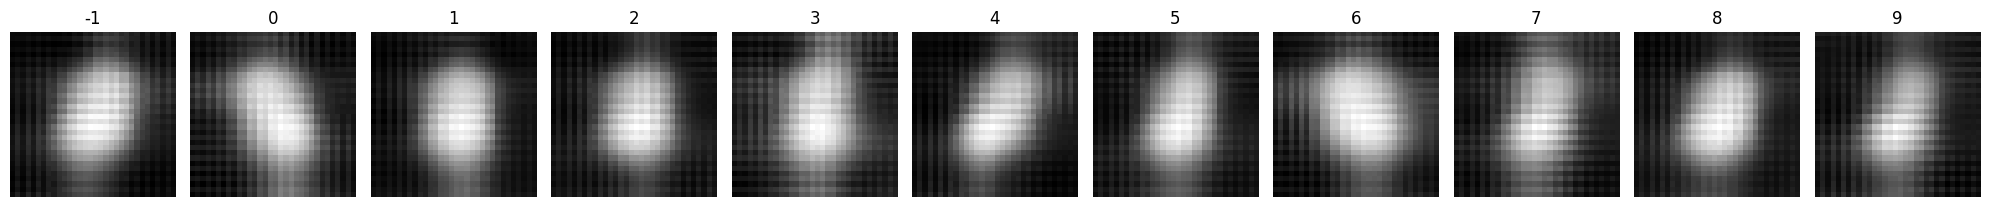

Epoch 2/100
468/468 [==============================] - 62s 132ms/step - loss: 0.1455 - noise_loss: 0.1243 - kl_loss: 2.1170 - val_loss: 3.6066 - val_noise_loss: 0.2520 - val_image_loss: 0.2520 - val_kl_loss: 335.4610 - learning_rate: 0.0050


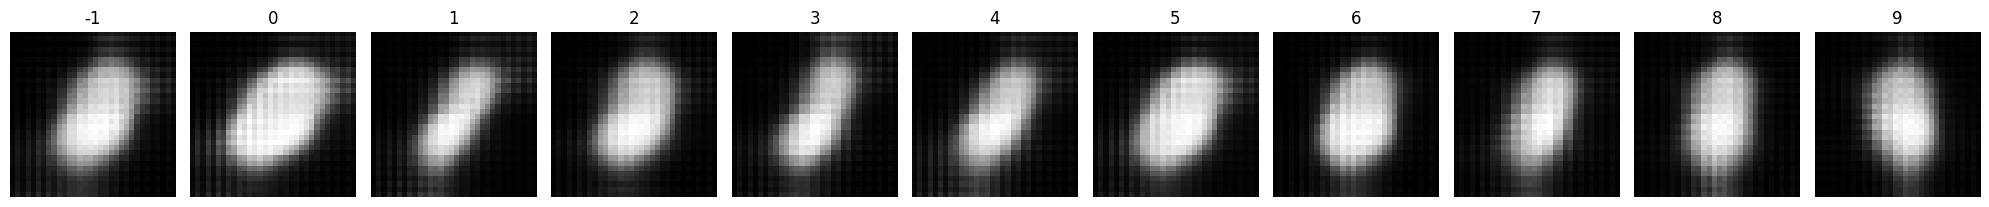

Epoch 3/100
468/468 [==============================] - 70s 149ms/step - loss: 0.1404 - noise_loss: 0.1148 - kl_loss: 2.5566 - val_loss: 1.3579 - val_noise_loss: 0.2159 - val_image_loss: 0.2159 - val_kl_loss: 114.1983 - learning_rate: 0.0050


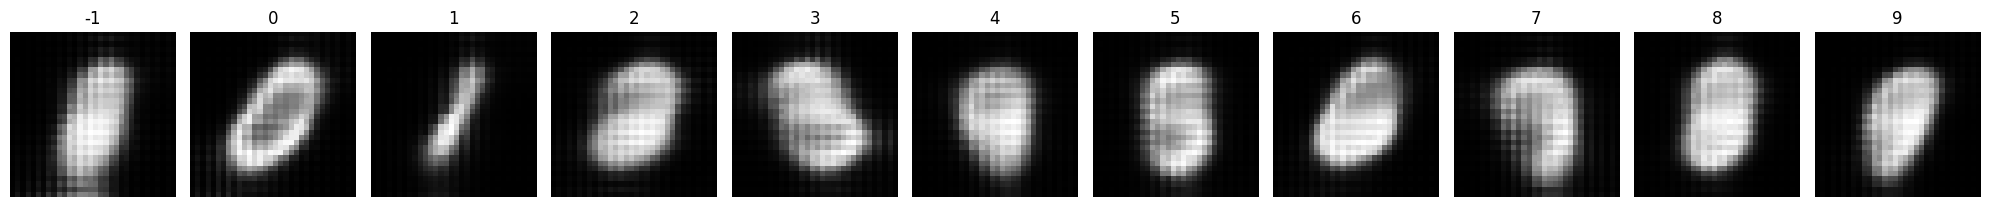

Epoch 4/100
468/468 [==============================] - 68s 145ms/step - loss: 0.1378 - noise_loss: 0.1095 - kl_loss: 2.8331 - val_loss: 0.5134 - val_noise_loss: 0.1637 - val_image_loss: 0.1637 - val_kl_loss: 34.9760 - learning_rate: 0.0050


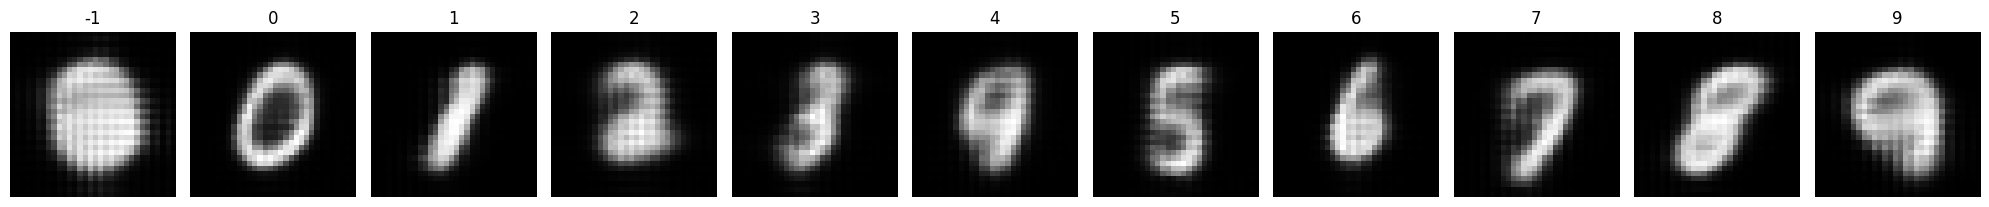

Epoch 5/100
468/468 [==============================] - 200s 429ms/step - loss: 0.1361 - noise_loss: 0.1061 - kl_loss: 3.0009 - val_loss: 0.2381 - val_noise_loss: 0.1313 - val_image_loss: 0.1313 - val_kl_loss: 10.6795 - learning_rate: 0.0050


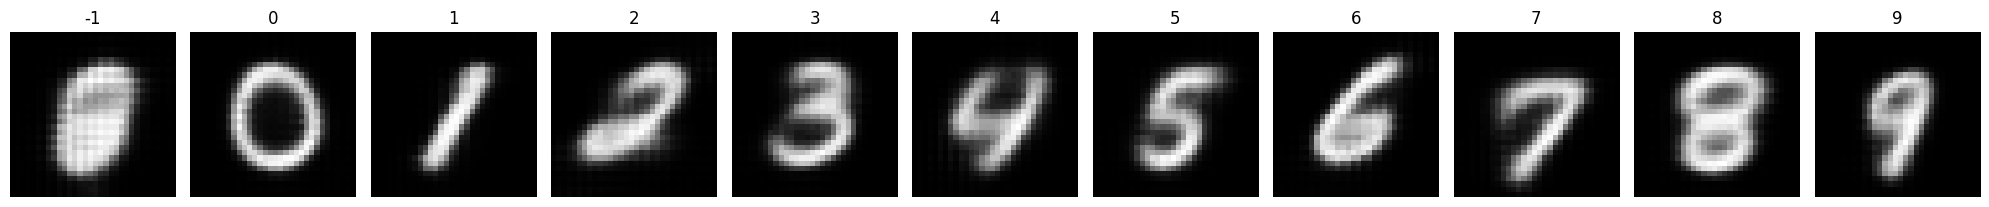

Epoch 6/100
468/468 [==============================] - 58s 123ms/step - loss: 0.1349 - noise_loss: 0.1040 - kl_loss: 3.0953 - val_loss: 0.1595 - val_noise_loss: 0.1146 - val_image_loss: 0.1146 - val_kl_loss: 4.4941 - learning_rate: 0.0050


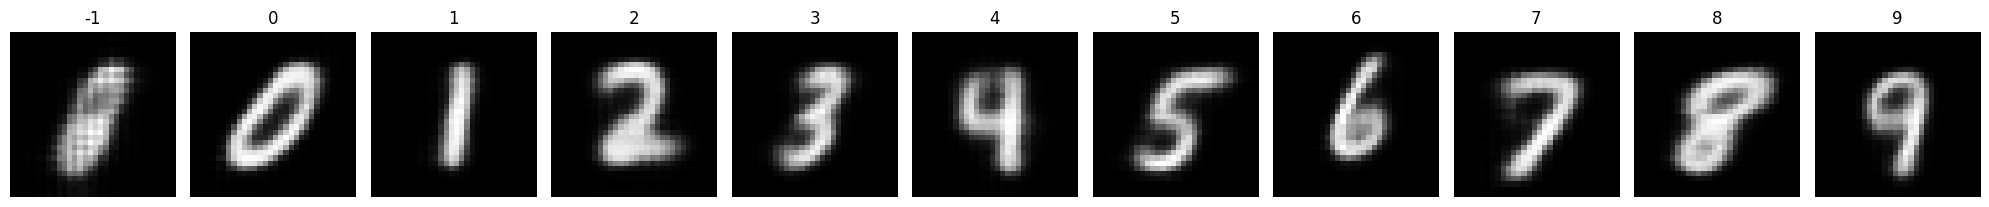

Epoch 7/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1341 - noise_loss: 0.1024 - kl_loss: 3.1702 - val_loss: 0.1382 - val_noise_loss: 0.1064 - val_image_loss: 0.1064 - val_kl_loss: 3.1816 - learning_rate: 0.0049


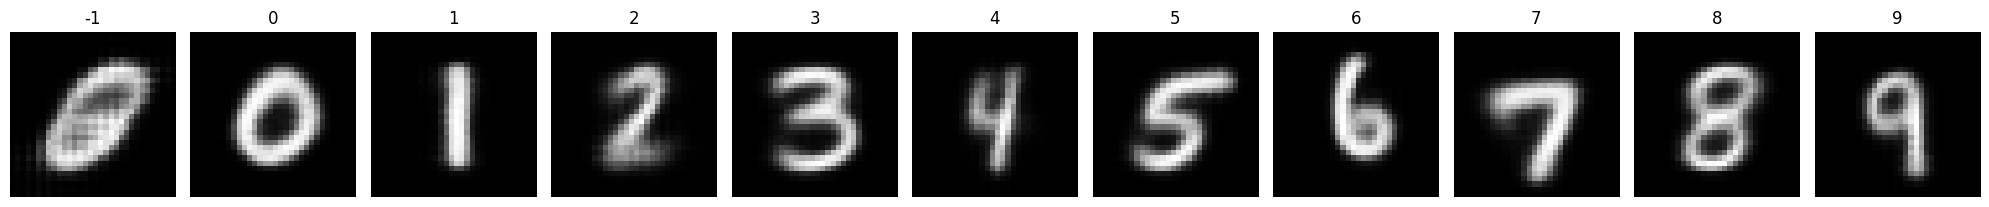

Epoch 8/100
468/468 [==============================] - 59s 125ms/step - loss: 0.1335 - noise_loss: 0.1012 - kl_loss: 3.2296 - val_loss: 0.1314 - val_noise_loss: 0.1018 - val_image_loss: 0.1018 - val_kl_loss: 2.9672 - learning_rate: 0.0049


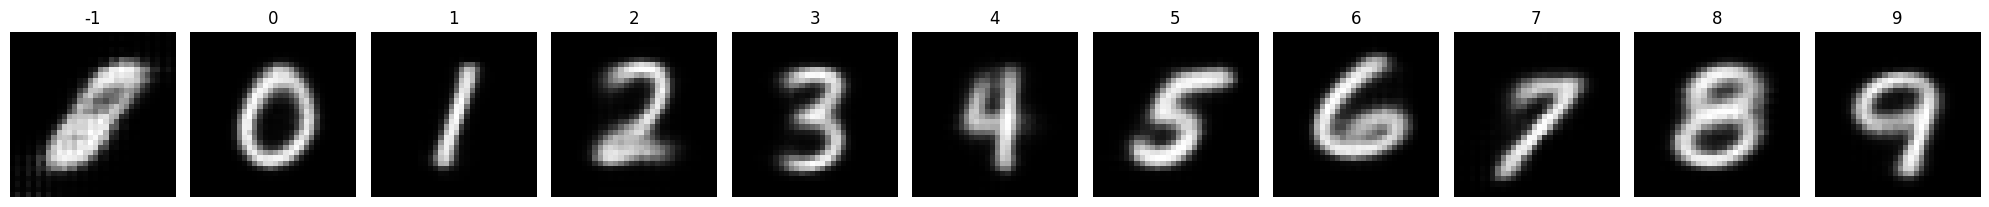

Epoch 9/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1330 - noise_loss: 0.1003 - kl_loss: 3.2676 - val_loss: 0.1293 - val_noise_loss: 0.0995 - val_image_loss: 0.0995 - val_kl_loss: 2.9796 - learning_rate: 0.0049


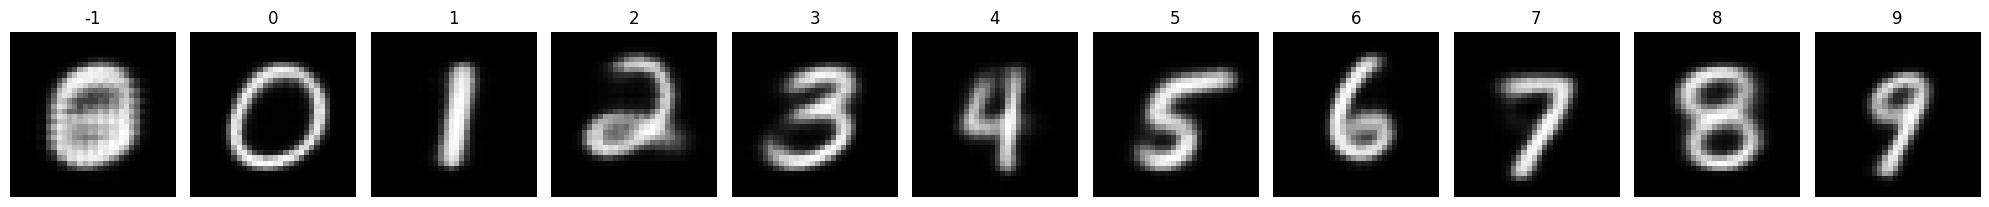

Epoch 10/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1327 - noise_loss: 0.0994 - kl_loss: 3.3294 - val_loss: 0.1283 - val_noise_loss: 0.0978 - val_image_loss: 0.0978 - val_kl_loss: 3.0502 - learning_rate: 0.0049


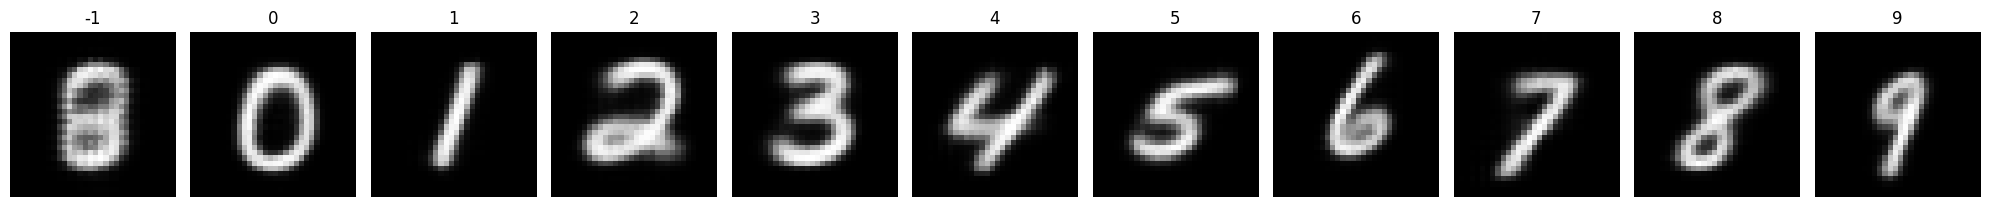

Epoch 11/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1323 - noise_loss: 0.0988 - kl_loss: 3.3529 - val_loss: 0.1273 - val_noise_loss: 0.0961 - val_image_loss: 0.0961 - val_kl_loss: 3.1154 - learning_rate: 0.0049


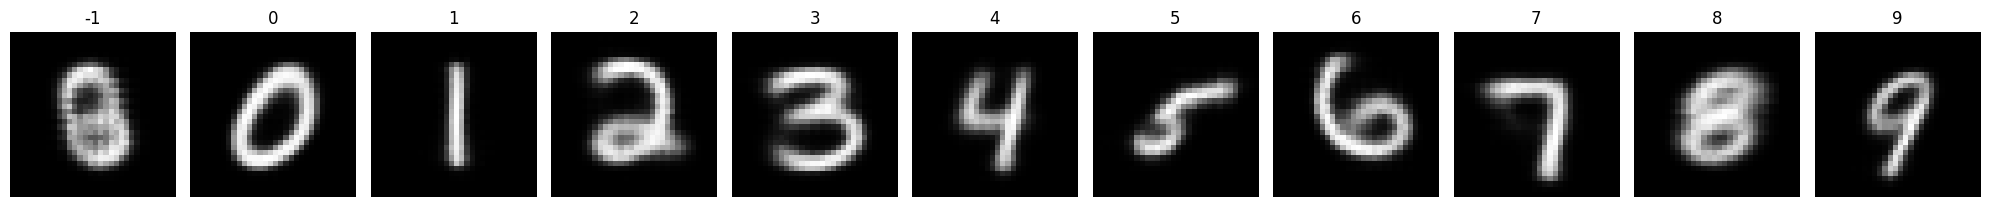

Epoch 12/100
468/468 [==============================] - 58s 124ms/step - loss: 262.4763 - noise_loss: 0.1210 - kl_loss: 26235.5098 - val_loss: 0.2915 - val_noise_loss: 0.0980 - val_image_loss: 0.0980 - val_kl_loss: 19.3472 - learning_rate: 0.0048


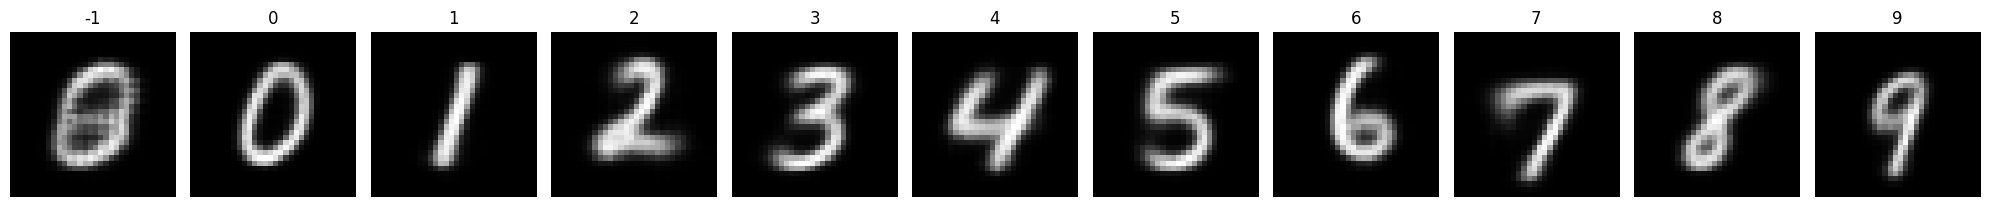

Epoch 13/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1318 - noise_loss: 0.0989 - kl_loss: 3.2876 - val_loss: 0.2691 - val_noise_loss: 0.0972 - val_image_loss: 0.0972 - val_kl_loss: 17.1880 - learning_rate: 0.0048


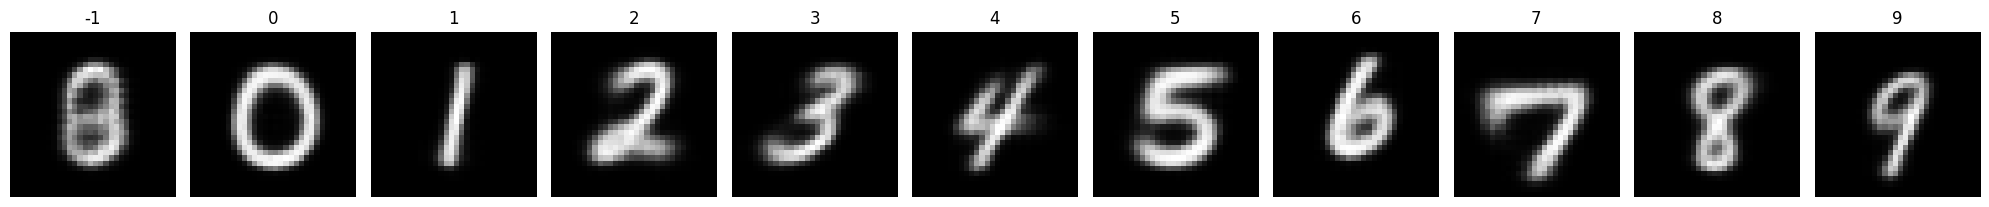

Epoch 14/100
468/468 [==============================] - 57s 123ms/step - loss: 0.1312 - noise_loss: 0.0974 - kl_loss: 3.3818 - val_loss: 0.2103 - val_noise_loss: 0.0957 - val_image_loss: 0.0957 - val_kl_loss: 11.4633 - learning_rate: 0.0048


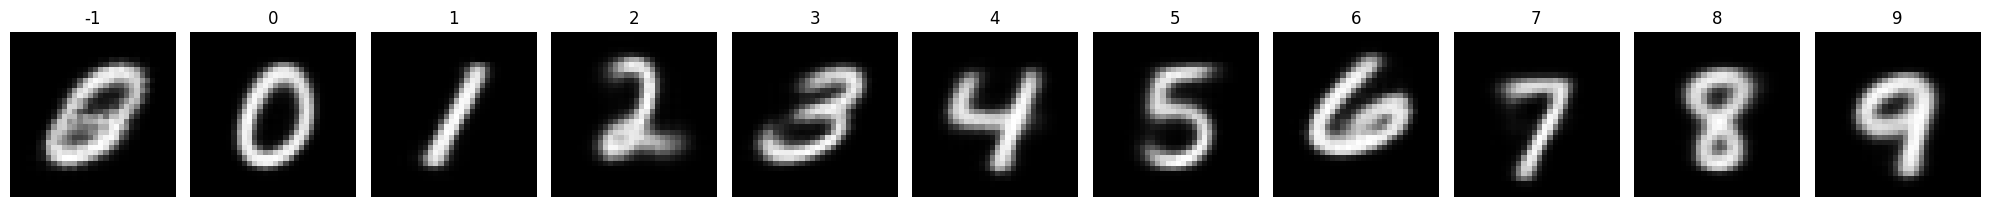

Epoch 15/100
468/468 [==============================] - 58s 125ms/step - loss: 0.1308 - noise_loss: 0.0966 - kl_loss: 3.4148 - val_loss: 0.1685 - val_noise_loss: 0.0943 - val_image_loss: 0.0943 - val_kl_loss: 7.4236 - learning_rate: 0.0047


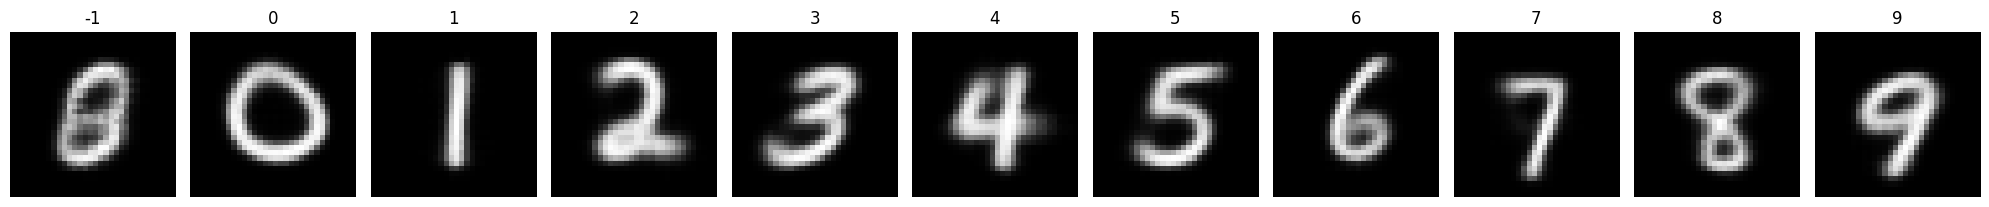

Epoch 16/100
468/468 [==============================] - 57s 123ms/step - loss: 0.1305 - noise_loss: 0.0961 - kl_loss: 3.4394 - val_loss: 0.1464 - val_noise_loss: 0.0933 - val_image_loss: 0.0933 - val_kl_loss: 5.3125 - learning_rate: 0.0047


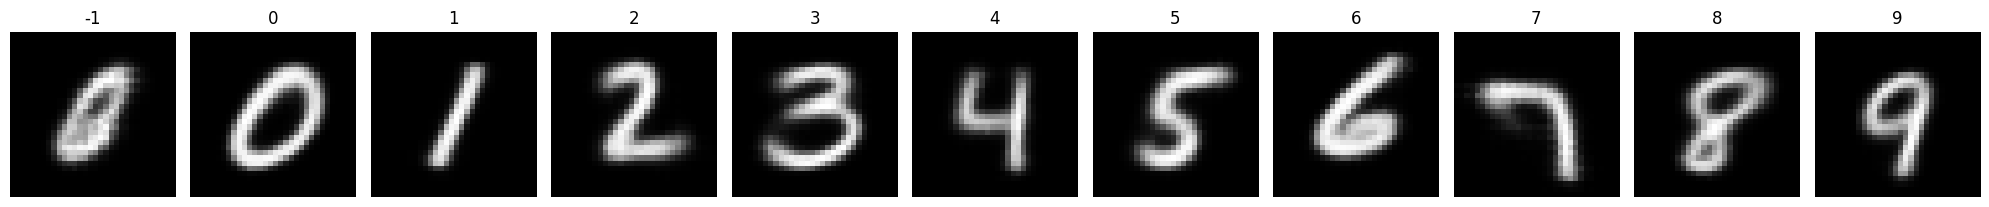

Epoch 17/100
468/468 [==============================] - 58s 123ms/step - loss: 0.1304 - noise_loss: 0.0957 - kl_loss: 3.4682 - val_loss: 0.1358 - val_noise_loss: 0.0923 - val_image_loss: 0.0923 - val_kl_loss: 4.3488 - learning_rate: 0.0047


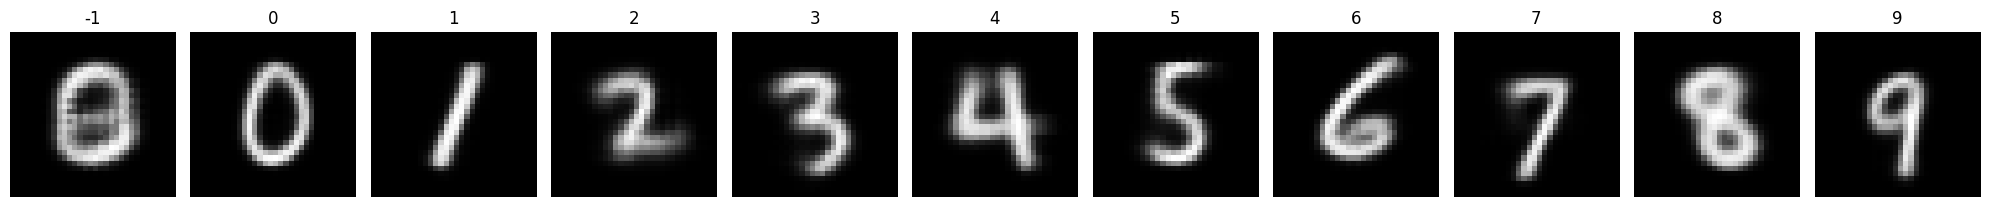

Epoch 18/100
468/468 [==============================] - 57s 122ms/step - loss: 0.1303 - noise_loss: 0.0954 - kl_loss: 3.4891 - val_loss: 0.1309 - val_noise_loss: 0.0917 - val_image_loss: 0.0917 - val_kl_loss: 3.9215 - learning_rate: 0.0046


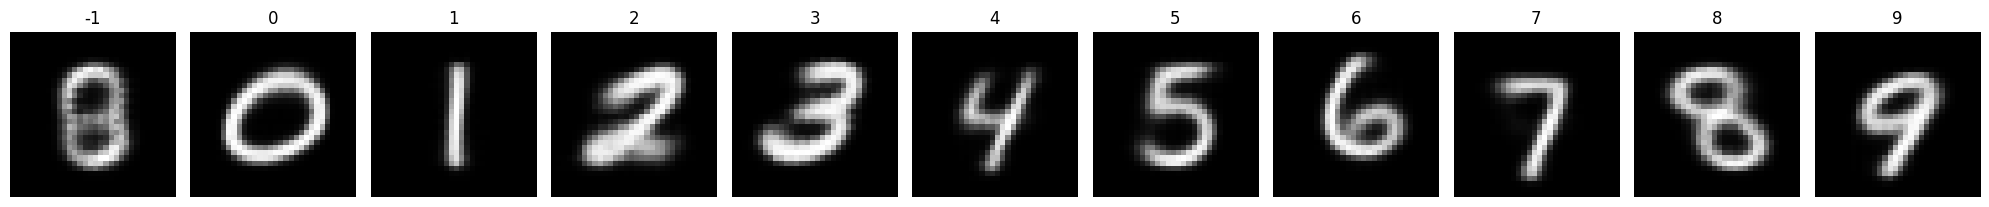

Epoch 19/100
468/468 [==============================] - 57s 122ms/step - loss: 0.1300 - noise_loss: 0.0951 - kl_loss: 3.4974 - val_loss: 0.1284 - val_noise_loss: 0.0911 - val_image_loss: 0.0911 - val_kl_loss: 3.7321 - learning_rate: 0.0046


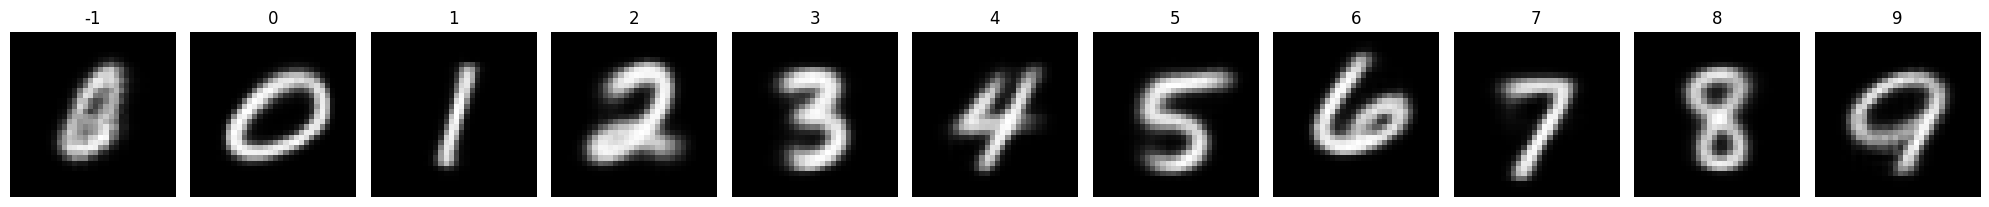

Epoch 20/100
468/468 [==============================] - 58s 123ms/step - loss: 0.1299 - noise_loss: 0.0948 - kl_loss: 3.5179 - val_loss: 0.1273 - val_noise_loss: 0.0909 - val_image_loss: 0.0909 - val_kl_loss: 3.6400 - learning_rate: 0.0045


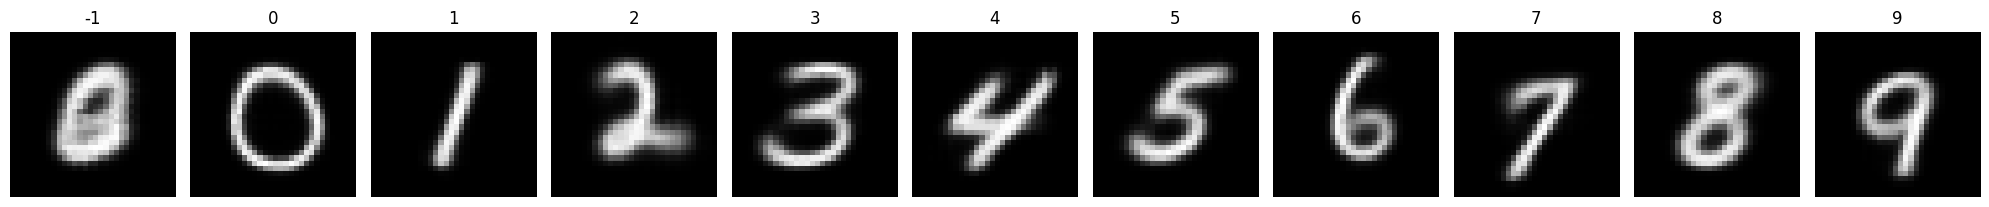

Epoch 21/100
468/468 [==============================] - 58s 123ms/step - loss: 0.1296 - noise_loss: 0.0943 - kl_loss: 3.5385 - val_loss: 0.1263 - val_noise_loss: 0.0903 - val_image_loss: 0.0903 - val_kl_loss: 3.5956 - learning_rate: 0.0045


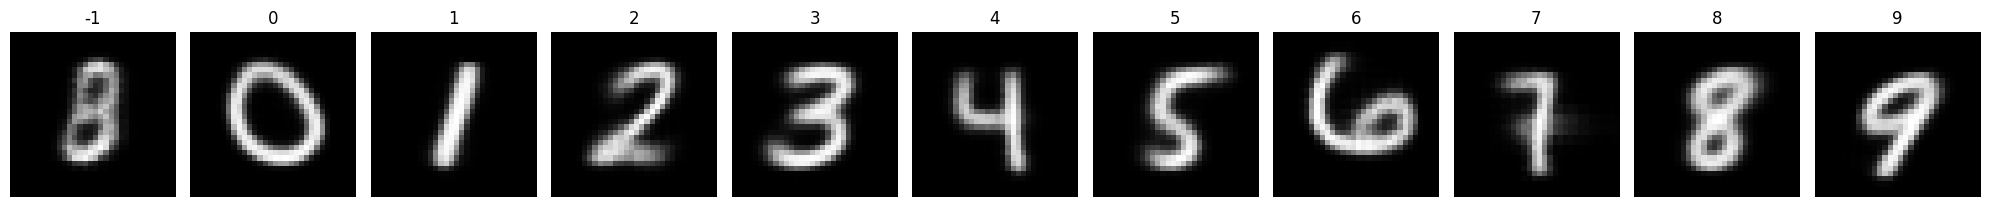

Epoch 22/100
468/468 [==============================] - 58s 123ms/step - loss: 0.1295 - noise_loss: 0.0942 - kl_loss: 3.5340 - val_loss: 0.1262 - val_noise_loss: 0.0904 - val_image_loss: 0.0904 - val_kl_loss: 3.5741 - learning_rate: 0.0044


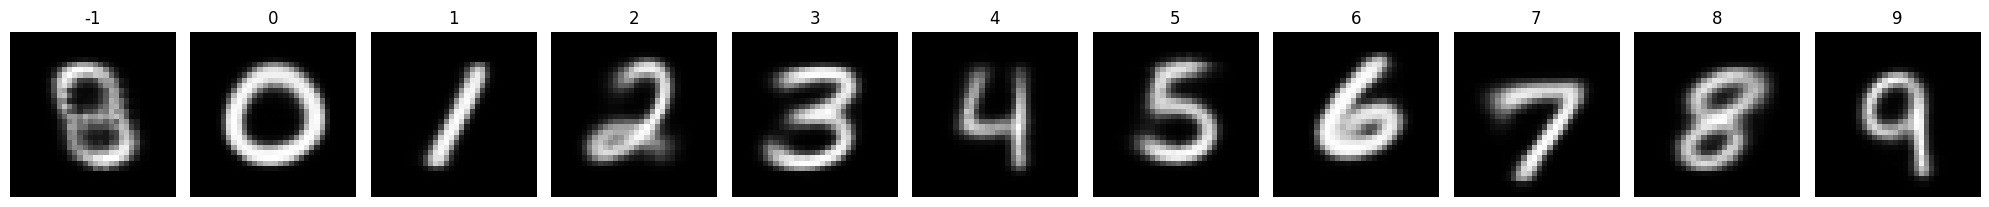

Epoch 23/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1293 - noise_loss: 0.0937 - kl_loss: 3.5582 - val_loss: 0.1255 - val_noise_loss: 0.0899 - val_image_loss: 0.0899 - val_kl_loss: 3.5654 - learning_rate: 0.0044


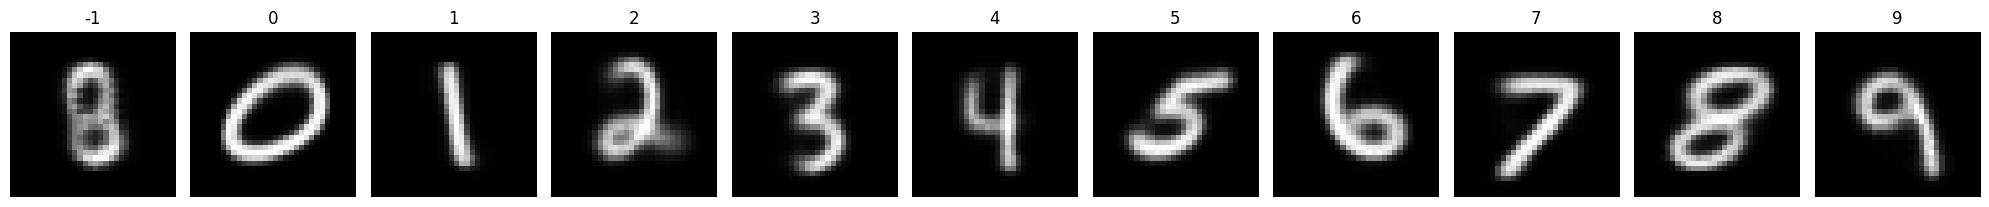

Epoch 24/100
468/468 [==============================] - 58s 123ms/step - loss: 0.2186 - noise_loss: 0.0983 - kl_loss: 12.0347 - val_loss: 0.1410 - val_noise_loss: 0.0897 - val_image_loss: 0.0897 - val_kl_loss: 5.1329 - learning_rate: 0.0043


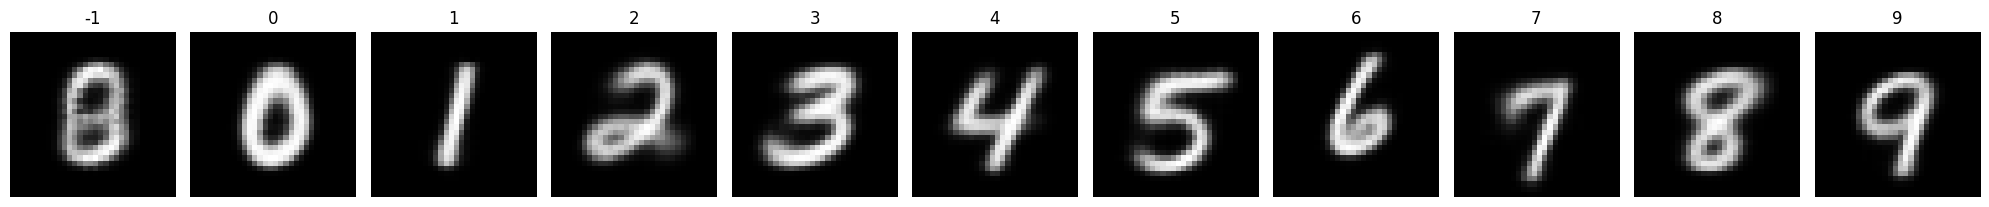

Epoch 25/100
468/468 [==============================] - 57s 123ms/step - loss: 0.1287 - noise_loss: 0.0933 - kl_loss: 3.5411 - val_loss: 0.1365 - val_noise_loss: 0.0895 - val_image_loss: 0.0895 - val_kl_loss: 4.6943 - learning_rate: 0.0043


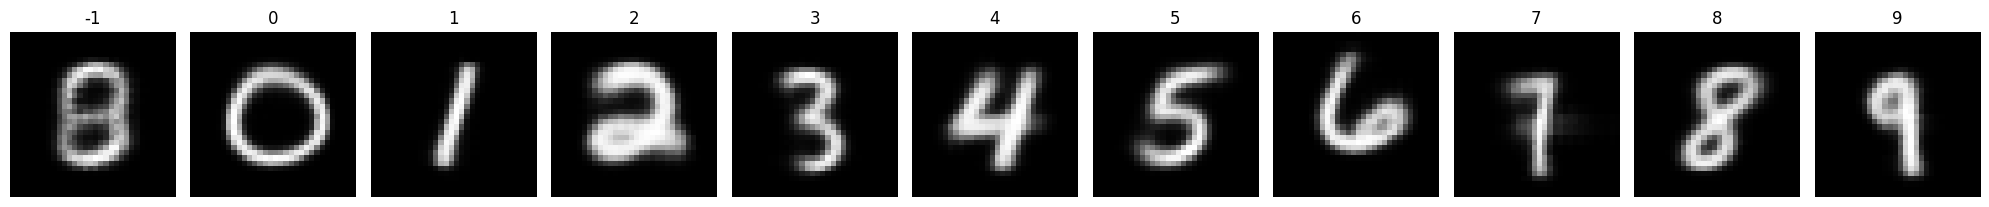

Epoch 26/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1288 - noise_loss: 0.0930 - kl_loss: 3.5831 - val_loss: 0.1309 - val_noise_loss: 0.0895 - val_image_loss: 0.0895 - val_kl_loss: 4.1361 - learning_rate: 0.0042


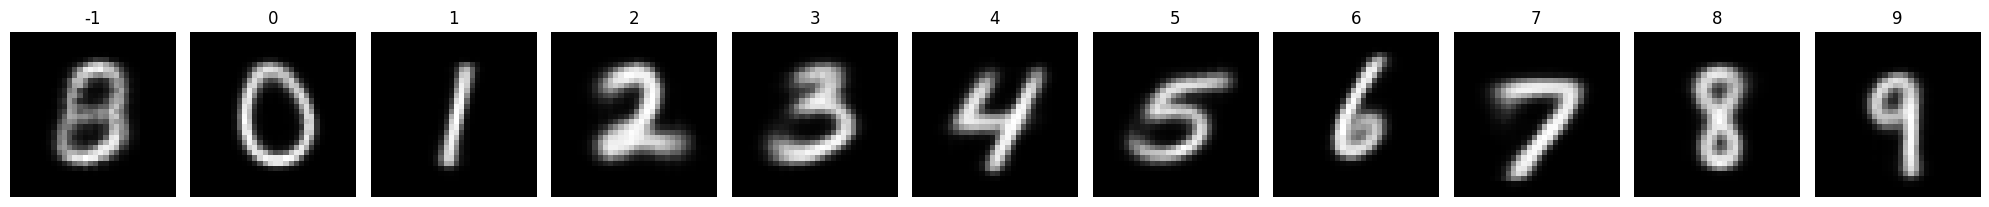

Epoch 27/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1284 - noise_loss: 0.0926 - kl_loss: 3.5782 - val_loss: 0.1276 - val_noise_loss: 0.0894 - val_image_loss: 0.0894 - val_kl_loss: 3.8165 - learning_rate: 0.0042


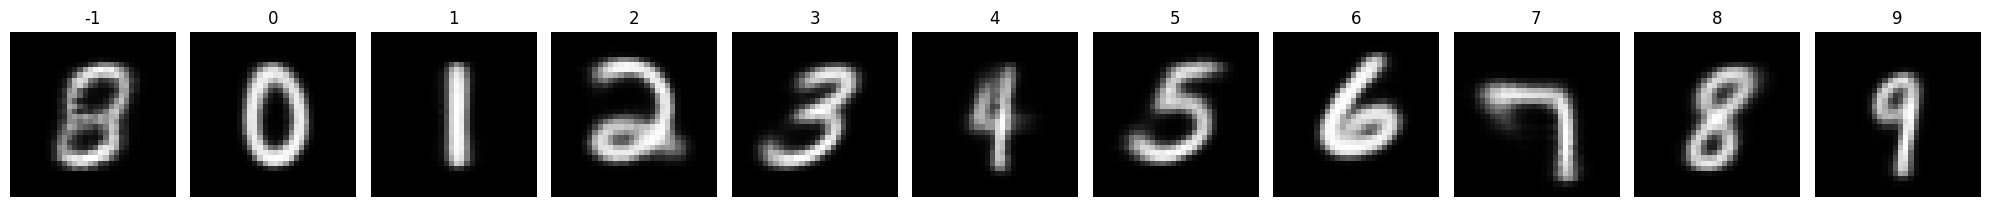

Epoch 28/100
468/468 [==============================] - 58s 124ms/step - loss: 0.1284 - noise_loss: 0.0924 - kl_loss: 3.6037 - val_loss: 0.1257 - val_noise_loss: 0.0888 - val_image_loss: 0.0888 - val_kl_loss: 3.6922 - learning_rate: 0.0041


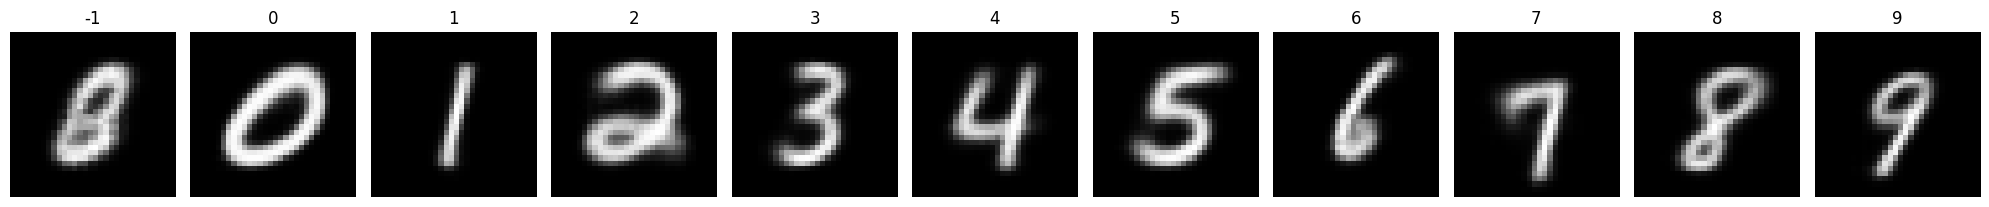

Epoch 29/100
468/468 [==============================] - 57s 123ms/step - loss: 0.1283 - noise_loss: 0.0923 - kl_loss: 3.6081 - val_loss: 0.1250 - val_noise_loss: 0.0885 - val_image_loss: 0.0885 - val_kl_loss: 3.6462 - learning_rate: 0.0040


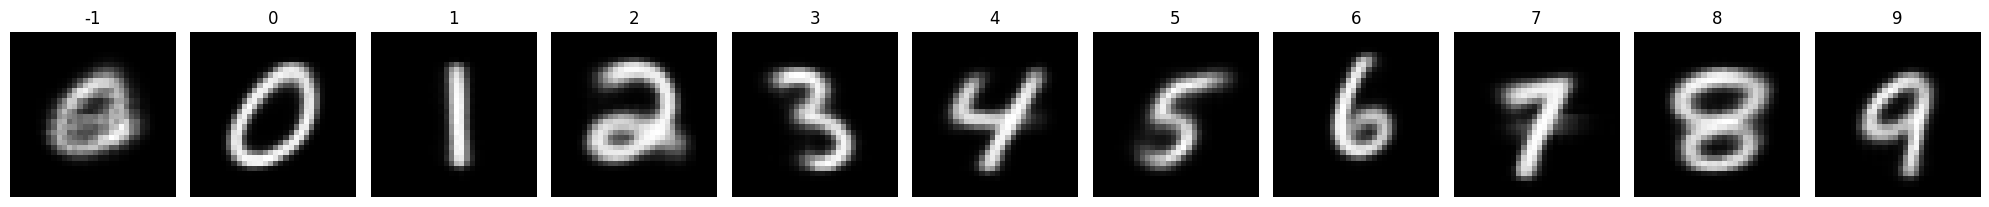

Epoch 30/100
468/468 [==============================] - 56s 120ms/step - loss: 0.1282 - noise_loss: 0.0919 - kl_loss: 3.6368 - val_loss: 0.1248 - val_noise_loss: 0.0885 - val_image_loss: 0.0885 - val_kl_loss: 3.6359 - learning_rate: 0.0040


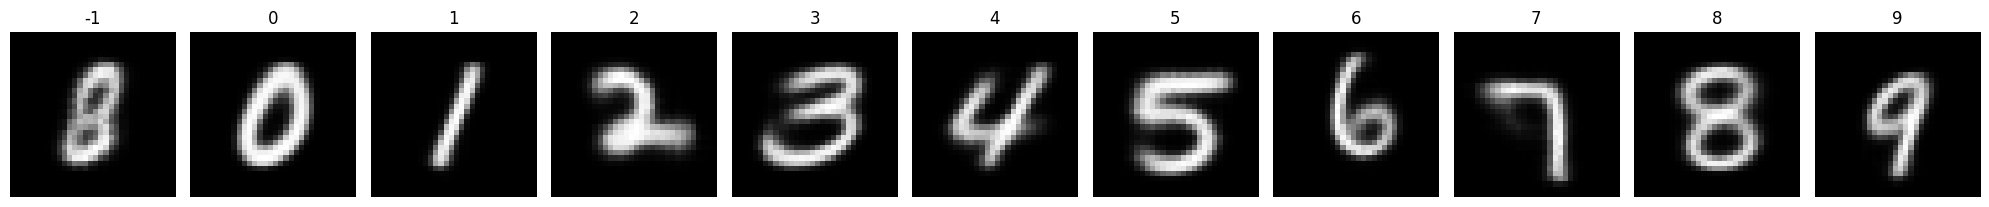

Epoch 31/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1282 - noise_loss: 0.0918 - kl_loss: 3.6489 - val_loss: 0.1248 - val_noise_loss: 0.0884 - val_image_loss: 0.0884 - val_kl_loss: 3.6375 - learning_rate: 0.0039


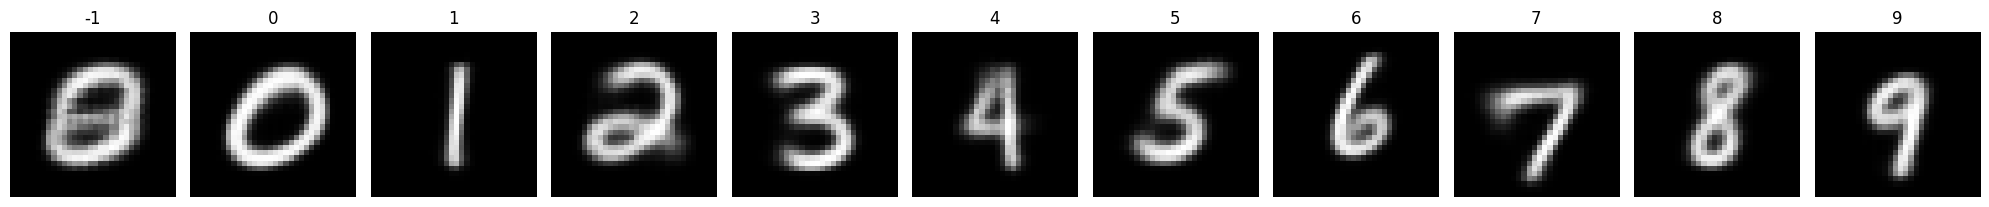

Epoch 32/100
468/468 [==============================] - 55s 116ms/step - loss: 0.1281 - noise_loss: 0.0915 - kl_loss: 3.6579 - val_loss: 0.1244 - val_noise_loss: 0.0880 - val_image_loss: 0.0880 - val_kl_loss: 3.6442 - learning_rate: 0.0038


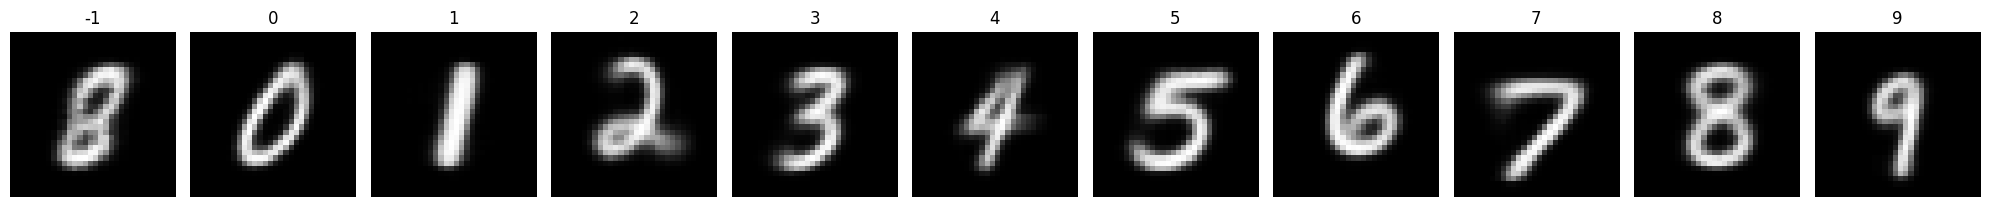

Epoch 33/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1279 - noise_loss: 0.0913 - kl_loss: 3.6575 - val_loss: 0.1244 - val_noise_loss: 0.0879 - val_image_loss: 0.0879 - val_kl_loss: 3.6423 - learning_rate: 0.0038


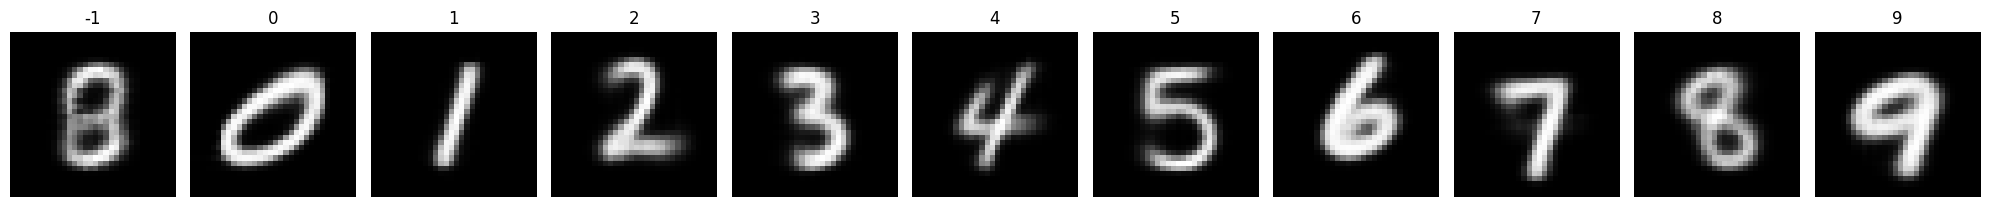

Epoch 34/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1278 - noise_loss: 0.0912 - kl_loss: 3.6614 - val_loss: 0.1243 - val_noise_loss: 0.0879 - val_image_loss: 0.0879 - val_kl_loss: 3.6472 - learning_rate: 0.0037


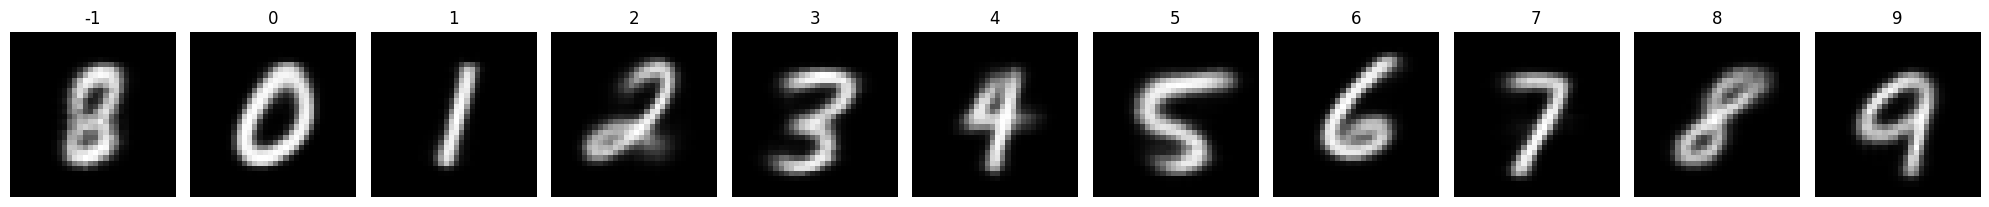

Epoch 35/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1277 - noise_loss: 0.0908 - kl_loss: 3.6888 - val_loss: 0.1241 - val_noise_loss: 0.0875 - val_image_loss: 0.0875 - val_kl_loss: 3.6620 - learning_rate: 0.0036


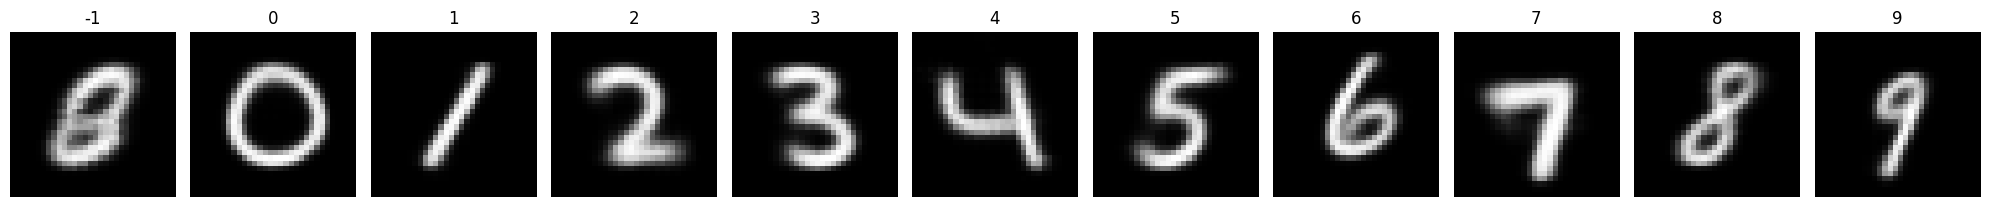

Epoch 36/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1277 - noise_loss: 0.0907 - kl_loss: 3.6991 - val_loss: 0.1241 - val_noise_loss: 0.0873 - val_image_loss: 0.0873 - val_kl_loss: 3.6755 - learning_rate: 0.0036


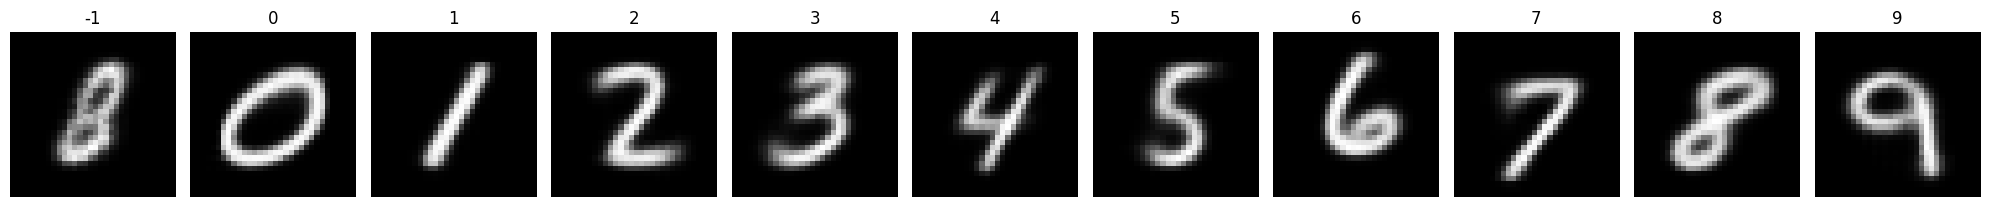

Epoch 37/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1274 - noise_loss: 0.0906 - kl_loss: 3.6809 - val_loss: 0.1241 - val_noise_loss: 0.0873 - val_image_loss: 0.0873 - val_kl_loss: 3.6768 - learning_rate: 0.0035


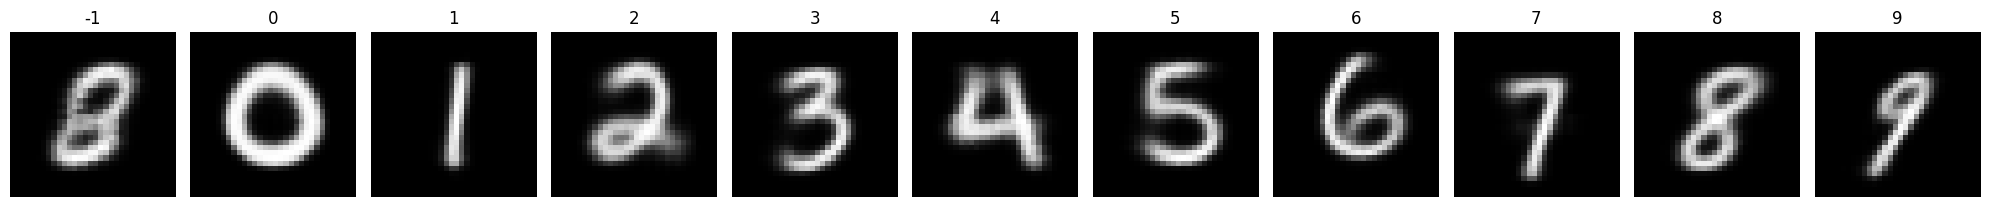

Epoch 38/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1274 - noise_loss: 0.0904 - kl_loss: 3.6930 - val_loss: 0.1239 - val_noise_loss: 0.0871 - val_image_loss: 0.0871 - val_kl_loss: 3.6817 - learning_rate: 0.0034


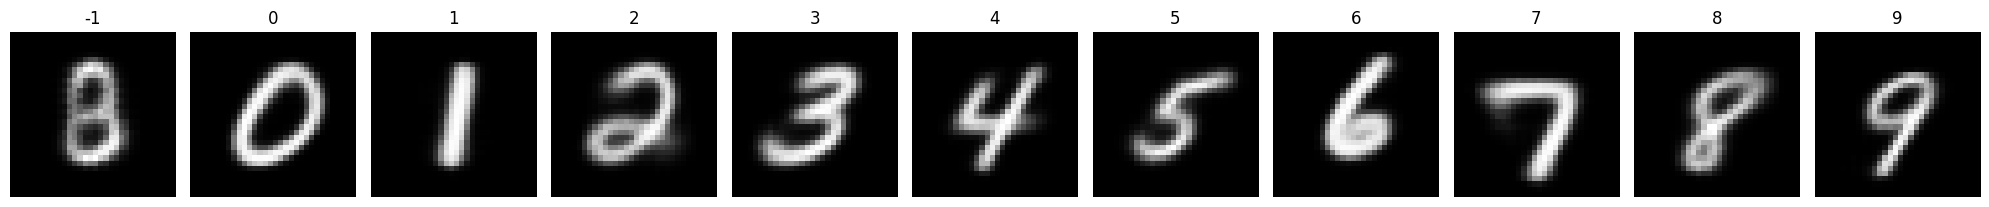

Epoch 39/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1273 - noise_loss: 0.0902 - kl_loss: 3.7096 - val_loss: 0.1239 - val_noise_loss: 0.0870 - val_image_loss: 0.0870 - val_kl_loss: 3.6933 - learning_rate: 0.0033


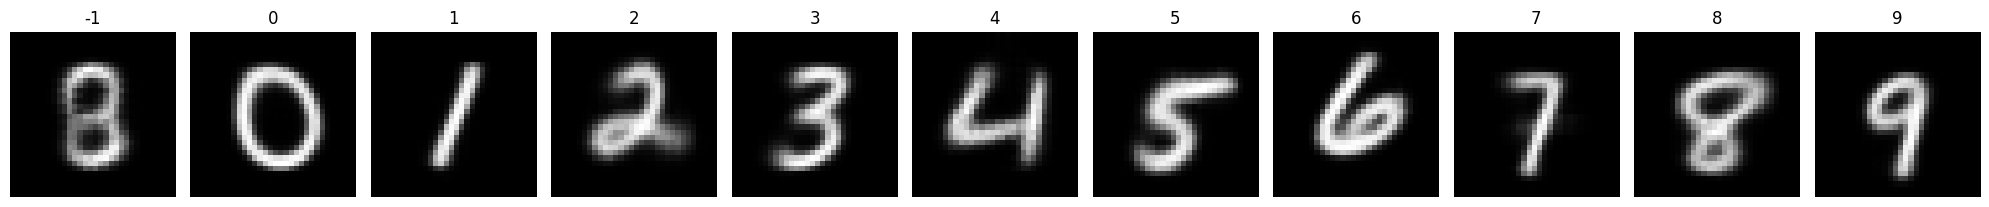

Epoch 40/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1270 - noise_loss: 0.0900 - kl_loss: 3.7058 - val_loss: 0.1241 - val_noise_loss: 0.0871 - val_image_loss: 0.0871 - val_kl_loss: 3.6967 - learning_rate: 0.0033


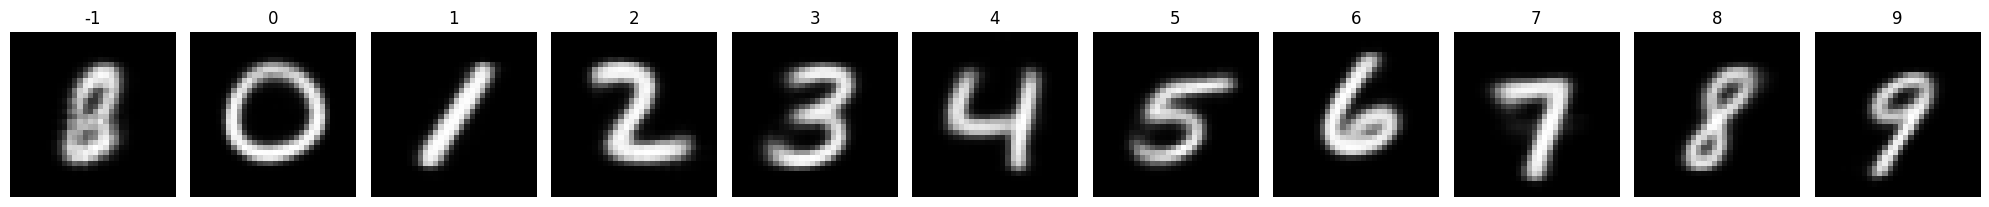

Epoch 41/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1269 - noise_loss: 0.0897 - kl_loss: 3.7237 - val_loss: 0.1238 - val_noise_loss: 0.0867 - val_image_loss: 0.0867 - val_kl_loss: 3.7043 - learning_rate: 0.0032


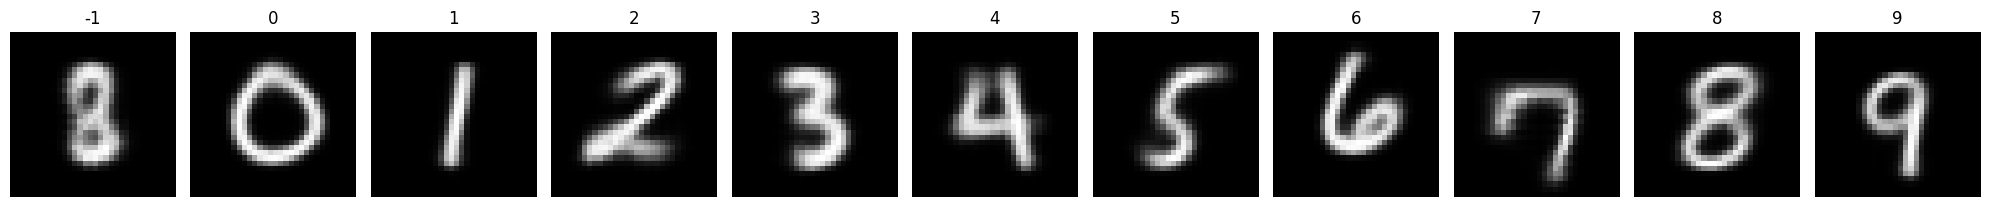

Epoch 42/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1267 - noise_loss: 0.0894 - kl_loss: 3.7332 - val_loss: 0.1238 - val_noise_loss: 0.0867 - val_image_loss: 0.0867 - val_kl_loss: 3.7136 - learning_rate: 0.0031


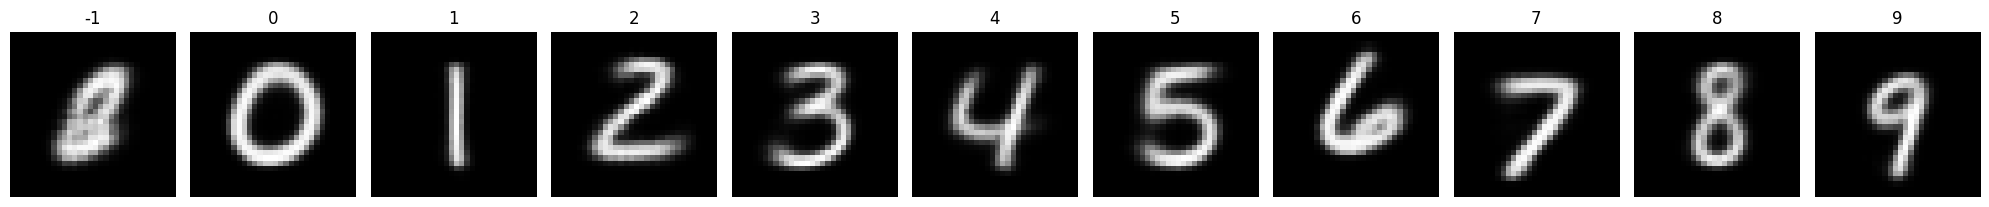

Epoch 43/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1268 - noise_loss: 0.0894 - kl_loss: 3.7382 - val_loss: 0.1240 - val_noise_loss: 0.0868 - val_image_loss: 0.0868 - val_kl_loss: 3.7228 - learning_rate: 0.0030


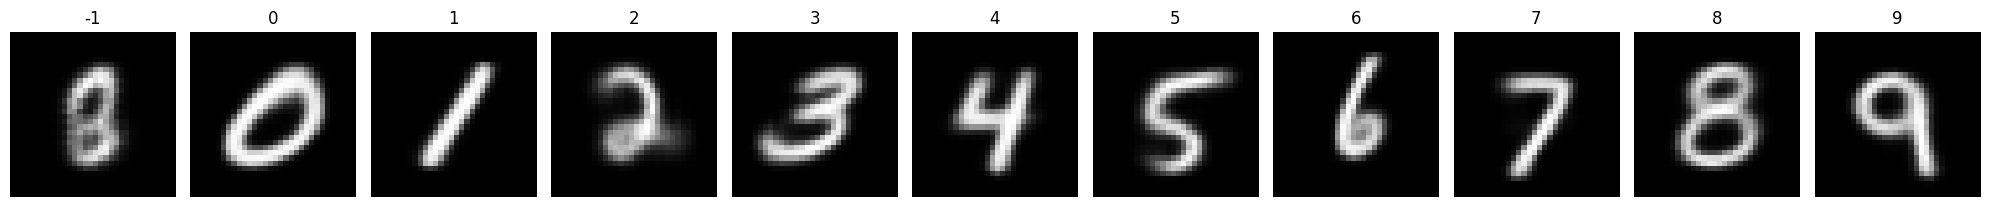

Epoch 44/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1266 - noise_loss: 0.0891 - kl_loss: 3.7523 - val_loss: 0.1237 - val_noise_loss: 0.0864 - val_image_loss: 0.0864 - val_kl_loss: 3.7353 - learning_rate: 0.0030


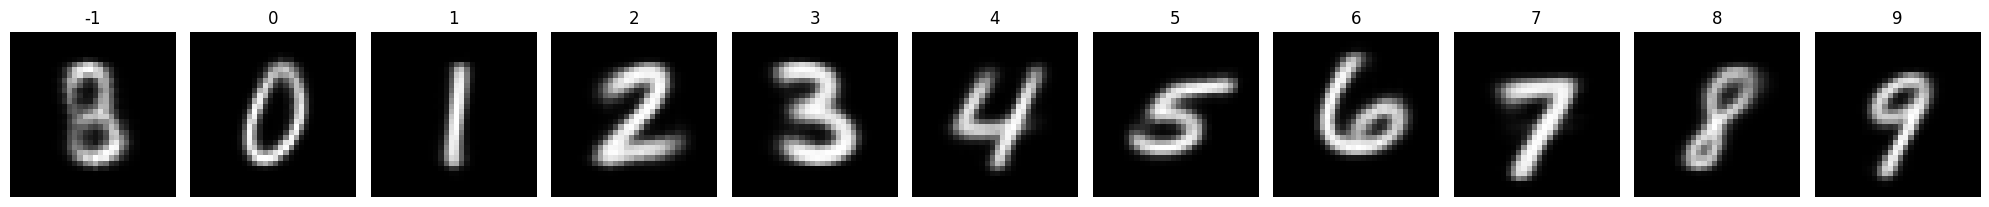

Epoch 45/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1265 - noise_loss: 0.0889 - kl_loss: 3.7649 - val_loss: 0.1240 - val_noise_loss: 0.0865 - val_image_loss: 0.0865 - val_kl_loss: 3.7459 - learning_rate: 0.0029


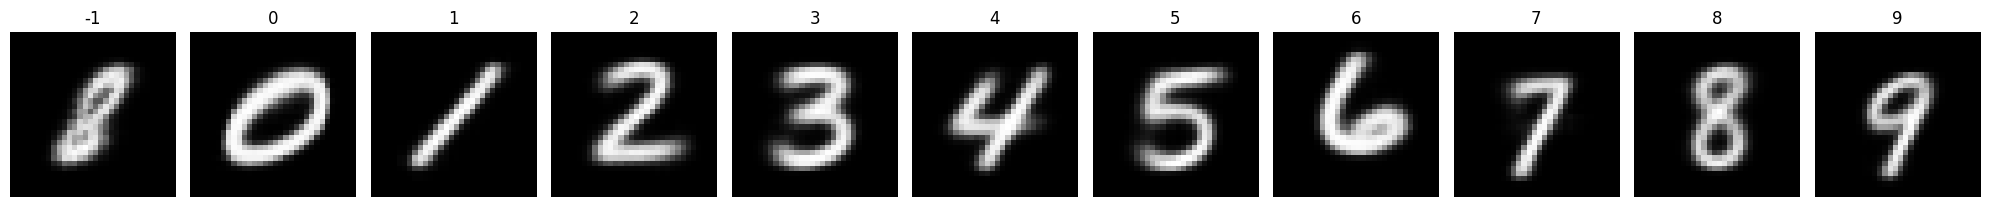

Epoch 46/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1264 - noise_loss: 0.0887 - kl_loss: 3.7663 - val_loss: 0.1237 - val_noise_loss: 0.0861 - val_image_loss: 0.0861 - val_kl_loss: 3.7534 - learning_rate: 0.0028


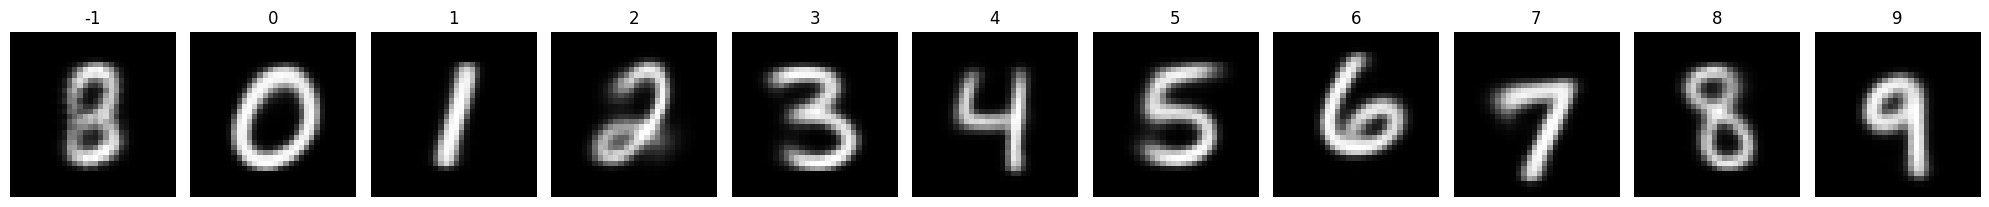

Epoch 47/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1263 - noise_loss: 0.0885 - kl_loss: 3.7798 - val_loss: 0.1234 - val_noise_loss: 0.0858 - val_image_loss: 0.0858 - val_kl_loss: 3.7607 - learning_rate: 0.0027


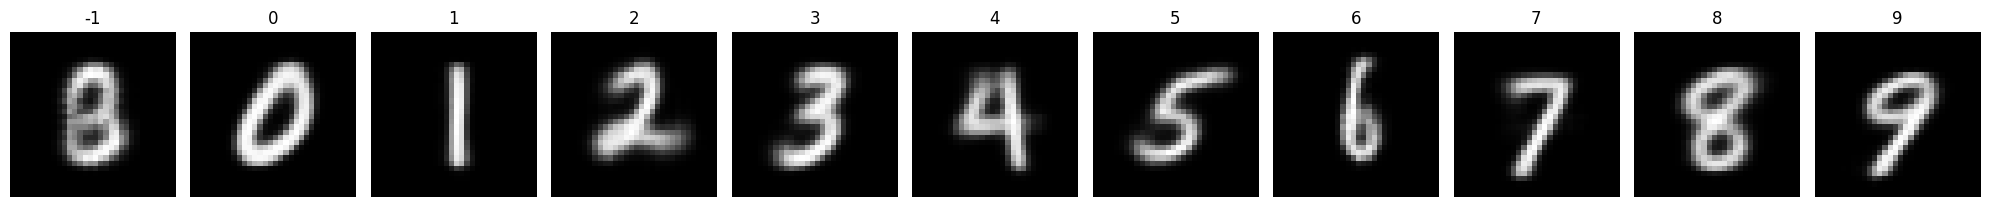

Epoch 48/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1261 - noise_loss: 0.0883 - kl_loss: 3.7755 - val_loss: 0.1234 - val_noise_loss: 0.0857 - val_image_loss: 0.0857 - val_kl_loss: 3.7688 - learning_rate: 0.0027


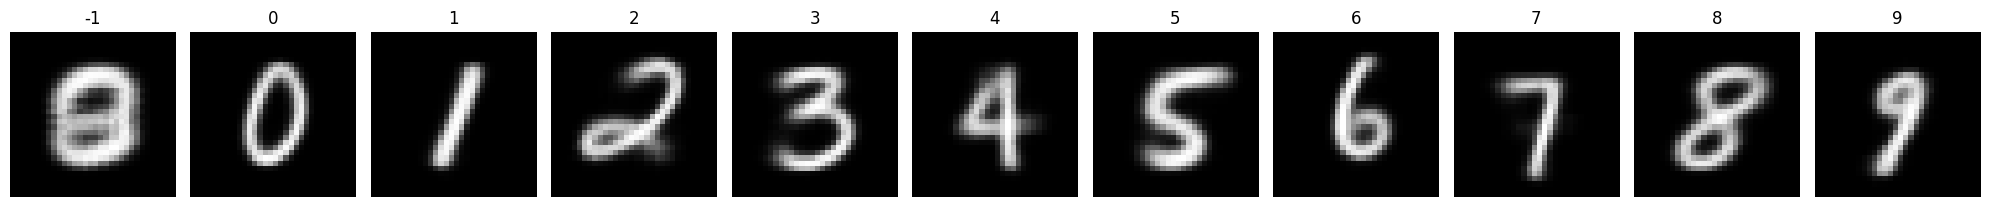

Epoch 49/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1261 - noise_loss: 0.0882 - kl_loss: 3.7831 - val_loss: 0.1235 - val_noise_loss: 0.0857 - val_image_loss: 0.0857 - val_kl_loss: 3.7768 - learning_rate: 0.0026


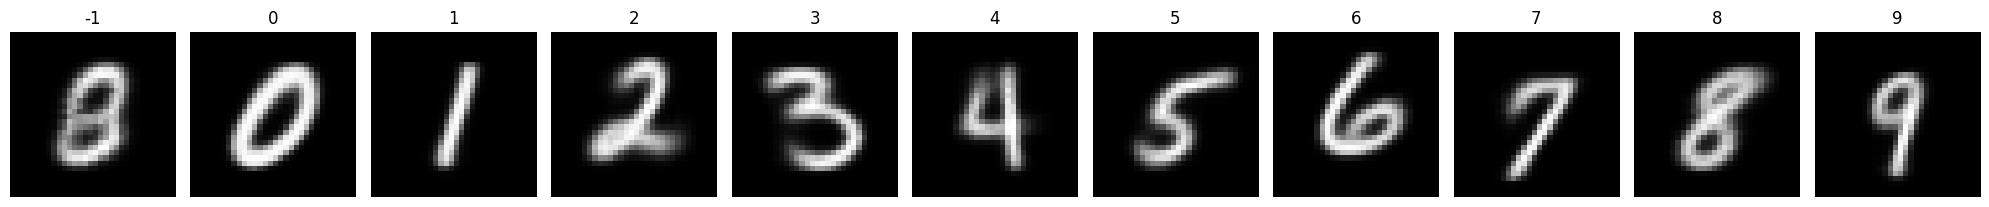

Epoch 50/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1260 - noise_loss: 0.0881 - kl_loss: 3.7872 - val_loss: 0.1234 - val_noise_loss: 0.0856 - val_image_loss: 0.0856 - val_kl_loss: 3.7817 - learning_rate: 0.0025


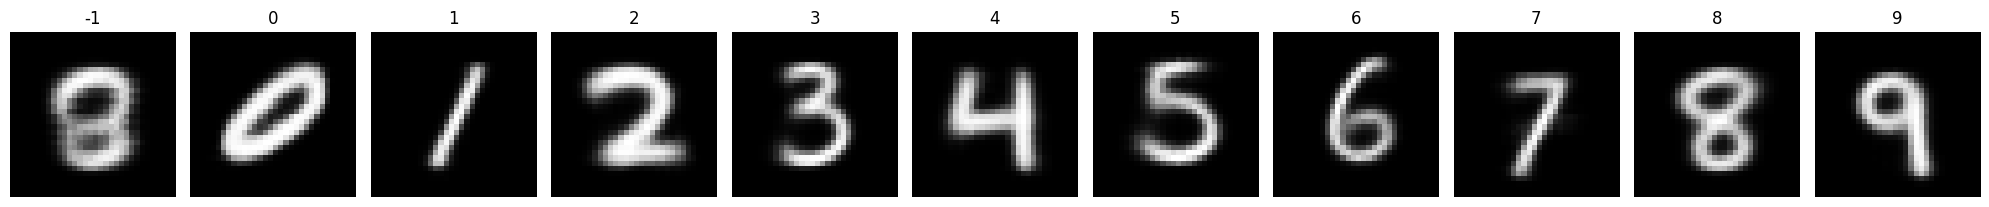

Epoch 51/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1257 - noise_loss: 0.0878 - kl_loss: 3.7870 - val_loss: 0.1236 - val_noise_loss: 0.0858 - val_image_loss: 0.0858 - val_kl_loss: 3.7828 - learning_rate: 0.0024


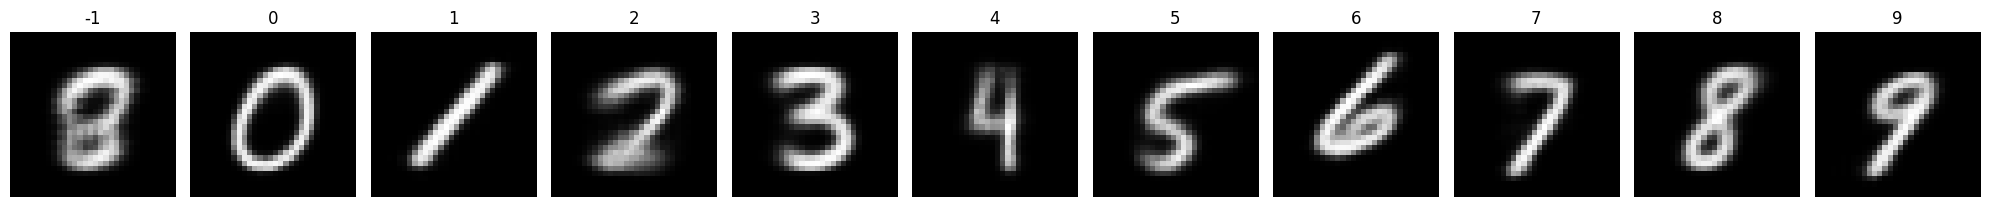

Epoch 52/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1257 - noise_loss: 0.0878 - kl_loss: 3.7981 - val_loss: 0.1235 - val_noise_loss: 0.0856 - val_image_loss: 0.0856 - val_kl_loss: 3.7878 - learning_rate: 0.0023


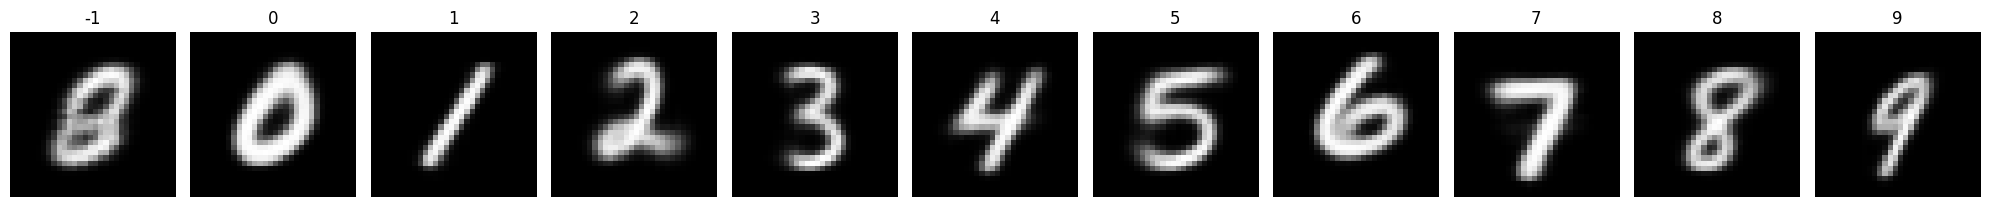

Epoch 53/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1257 - noise_loss: 0.0875 - kl_loss: 3.8224 - val_loss: 0.1233 - val_noise_loss: 0.0853 - val_image_loss: 0.0853 - val_kl_loss: 3.8023 - learning_rate: 0.0023


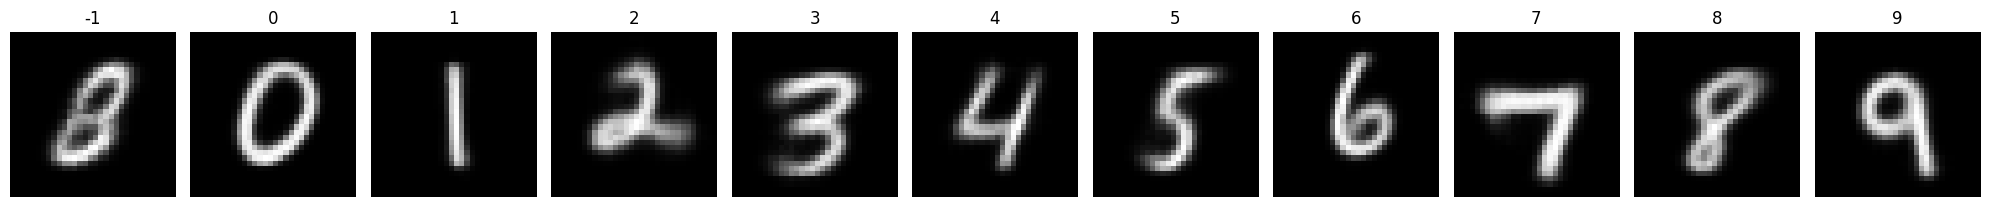

Epoch 54/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1255 - noise_loss: 0.0874 - kl_loss: 3.8111 - val_loss: 0.1232 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8063 - learning_rate: 0.0022


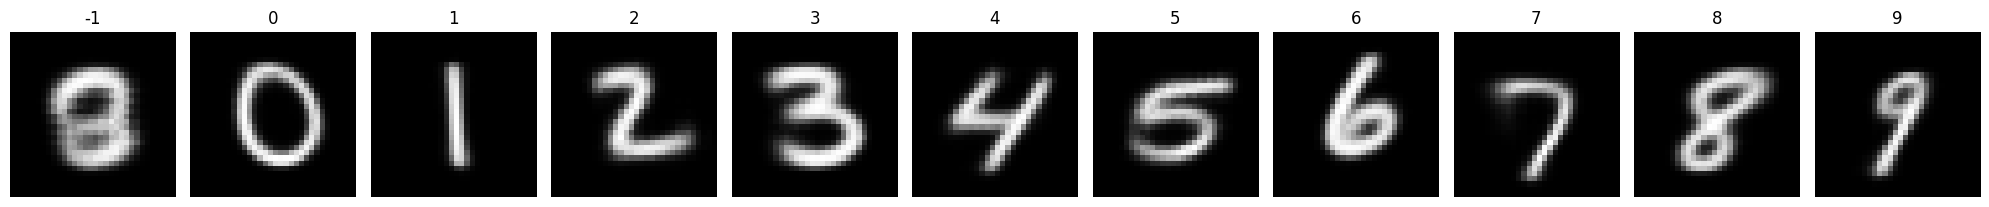

Epoch 55/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1254 - noise_loss: 0.0871 - kl_loss: 3.8258 - val_loss: 0.1234 - val_noise_loss: 0.0852 - val_image_loss: 0.0852 - val_kl_loss: 3.8149 - learning_rate: 0.0021


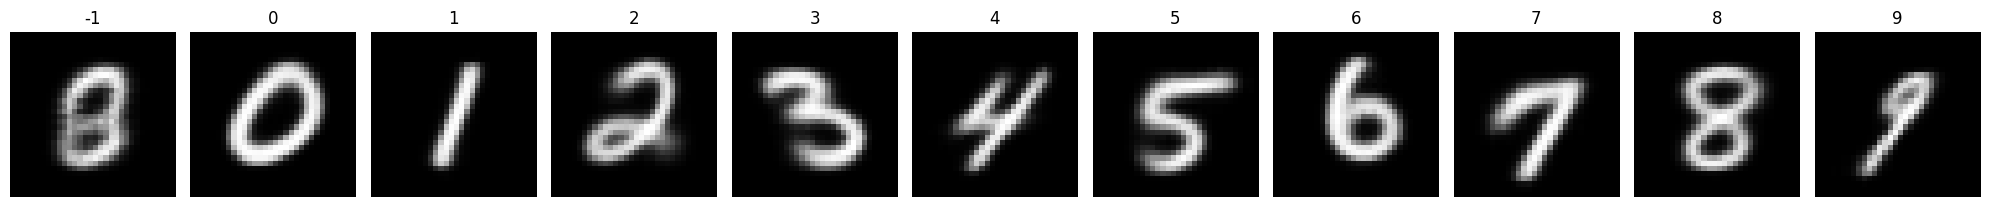

Epoch 56/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1253 - noise_loss: 0.0870 - kl_loss: 3.8336 - val_loss: 0.1234 - val_noise_loss: 0.0852 - val_image_loss: 0.0852 - val_kl_loss: 3.8218 - learning_rate: 0.0020


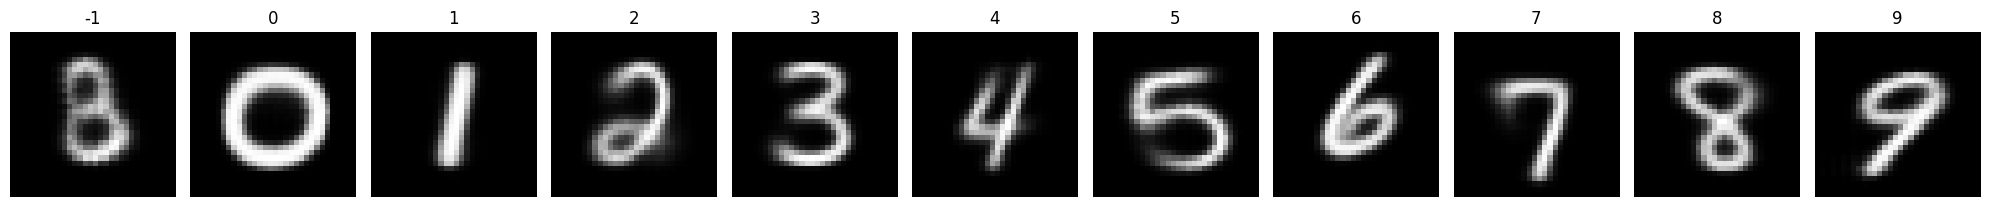

Epoch 57/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1253 - noise_loss: 0.0870 - kl_loss: 3.8363 - val_loss: 0.1234 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8275 - learning_rate: 0.0020


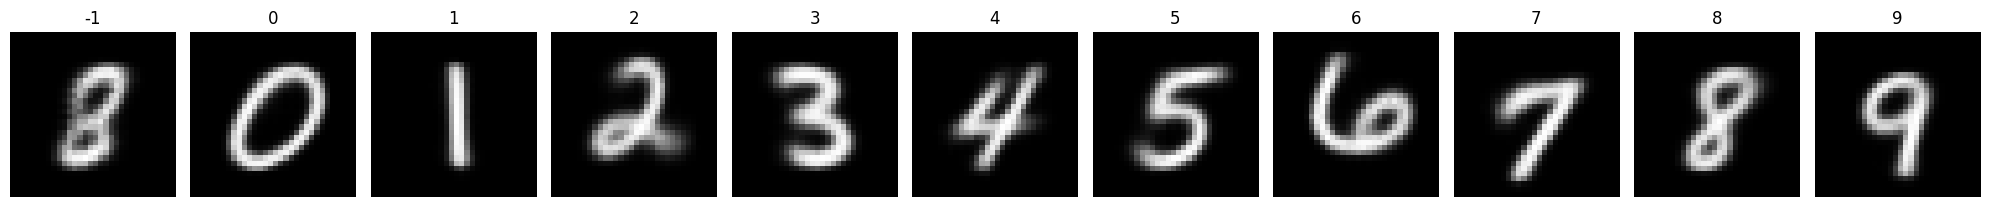

Epoch 58/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1251 - noise_loss: 0.0867 - kl_loss: 3.8406 - val_loss: 0.1235 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8327 - learning_rate: 0.0019


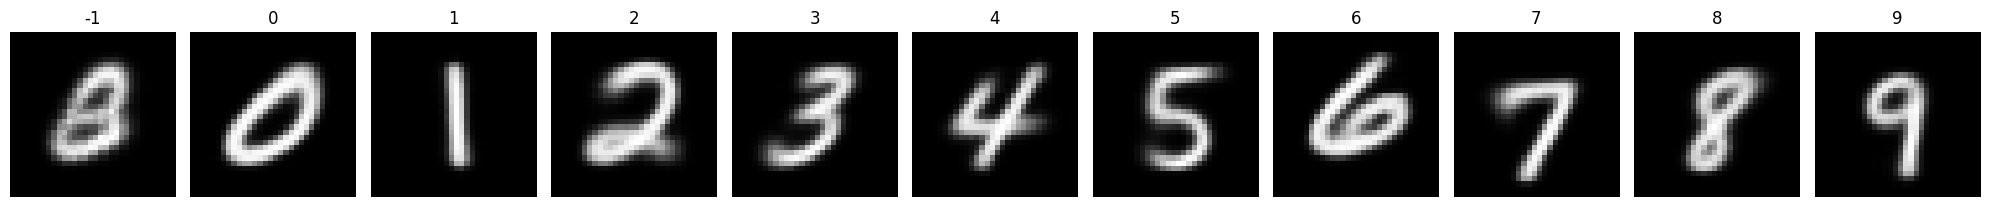

Epoch 59/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1251 - noise_loss: 0.0867 - kl_loss: 3.8490 - val_loss: 0.1235 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8391 - learning_rate: 0.0018


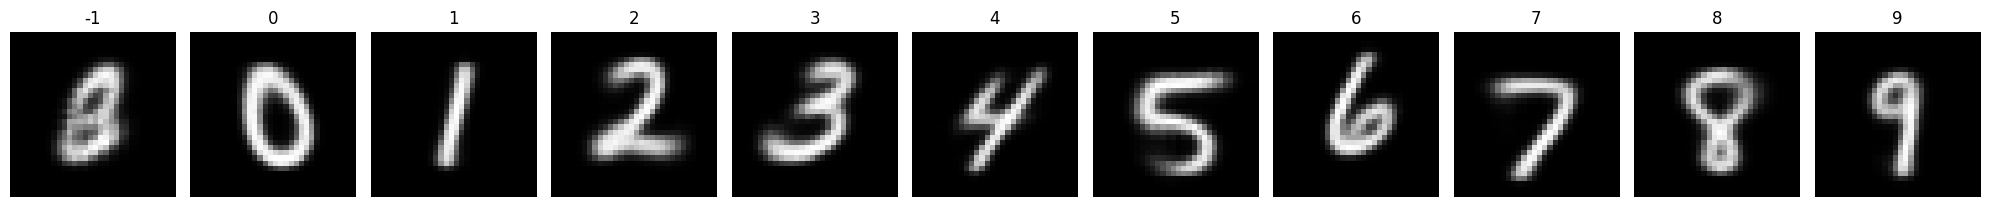

Epoch 60/100
468/468 [==============================] - 55s 116ms/step - loss: 0.1249 - noise_loss: 0.0864 - kl_loss: 3.8503 - val_loss: 0.1233 - val_noise_loss: 0.0849 - val_image_loss: 0.0849 - val_kl_loss: 3.8433 - learning_rate: 0.0017


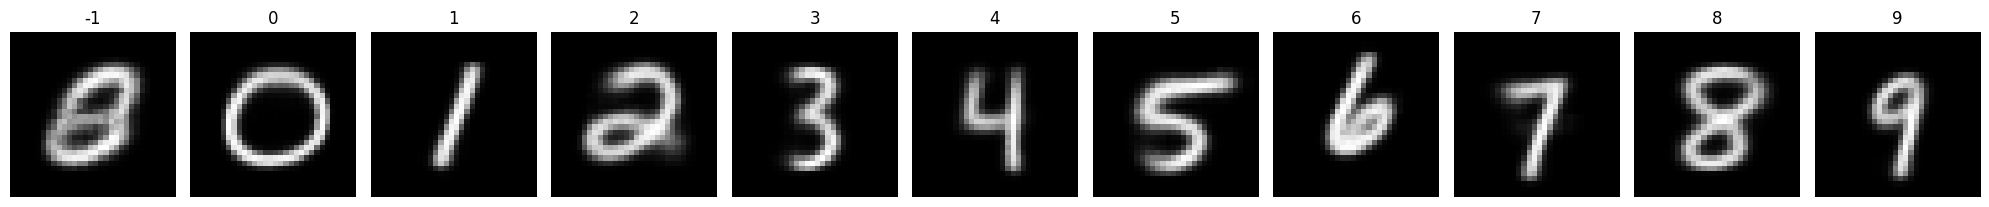

Epoch 61/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1248 - noise_loss: 0.0863 - kl_loss: 3.8574 - val_loss: 0.1232 - val_noise_loss: 0.0848 - val_image_loss: 0.0848 - val_kl_loss: 3.8473 - learning_rate: 0.0017


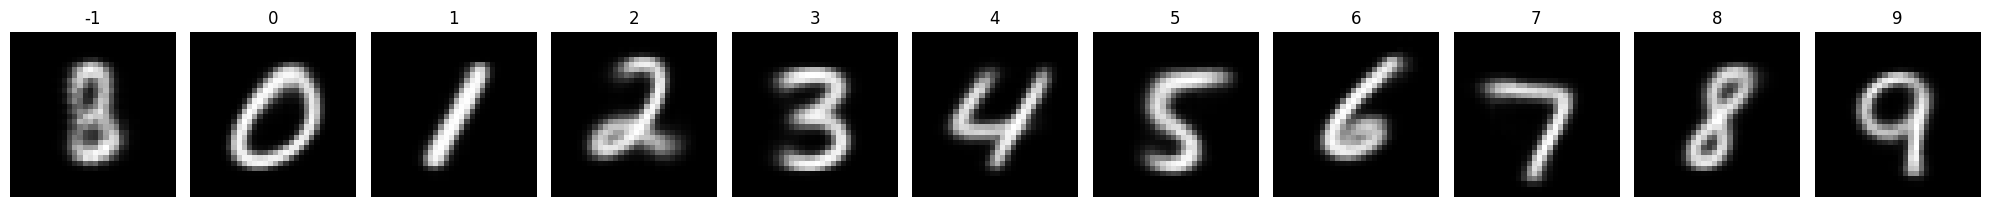

Epoch 62/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1247 - noise_loss: 0.0862 - kl_loss: 3.8483 - val_loss: 0.1236 - val_noise_loss: 0.0851 - val_image_loss: 0.0851 - val_kl_loss: 3.8461 - learning_rate: 0.0016


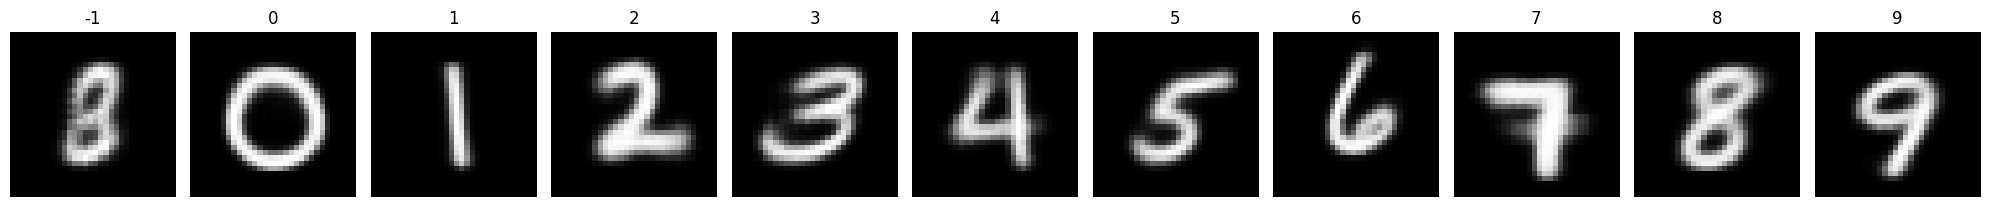

Epoch 63/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1247 - noise_loss: 0.0860 - kl_loss: 3.8771 - val_loss: 0.1231 - val_noise_loss: 0.0845 - val_image_loss: 0.0845 - val_kl_loss: 3.8555 - learning_rate: 0.0015


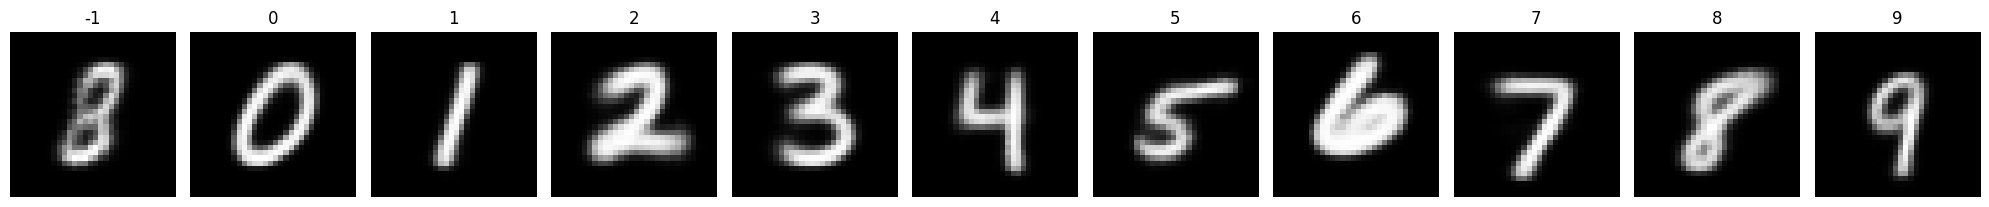

Epoch 64/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1246 - noise_loss: 0.0858 - kl_loss: 3.8832 - val_loss: 0.1233 - val_noise_loss: 0.0847 - val_image_loss: 0.0847 - val_kl_loss: 3.8624 - learning_rate: 0.0014


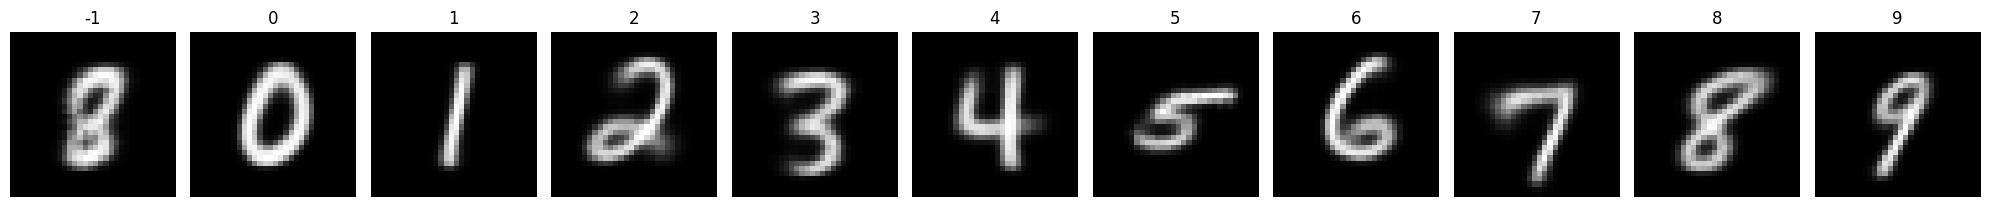

Epoch 65/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1245 - noise_loss: 0.0856 - kl_loss: 3.8886 - val_loss: 0.1233 - val_noise_loss: 0.0846 - val_image_loss: 0.0846 - val_kl_loss: 3.8717 - learning_rate: 0.0014


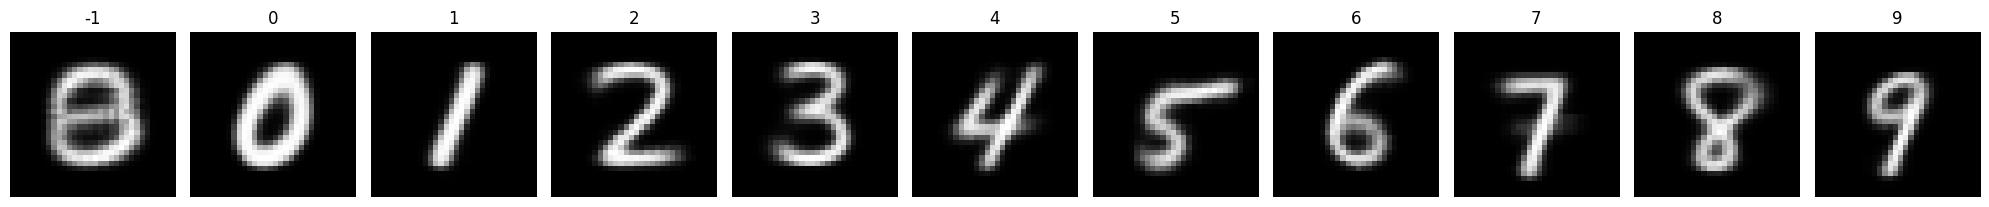

Epoch 66/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1244 - noise_loss: 0.0854 - kl_loss: 3.8930 - val_loss: 0.1232 - val_noise_loss: 0.0844 - val_image_loss: 0.0844 - val_kl_loss: 3.8777 - learning_rate: 0.0013


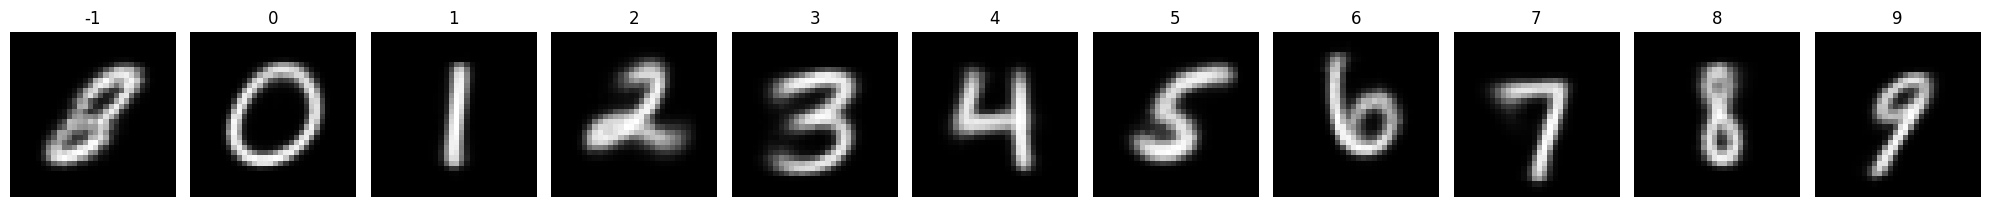

Epoch 67/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1242 - noise_loss: 0.0854 - kl_loss: 3.8862 - val_loss: 0.1231 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.8792 - learning_rate: 0.0012


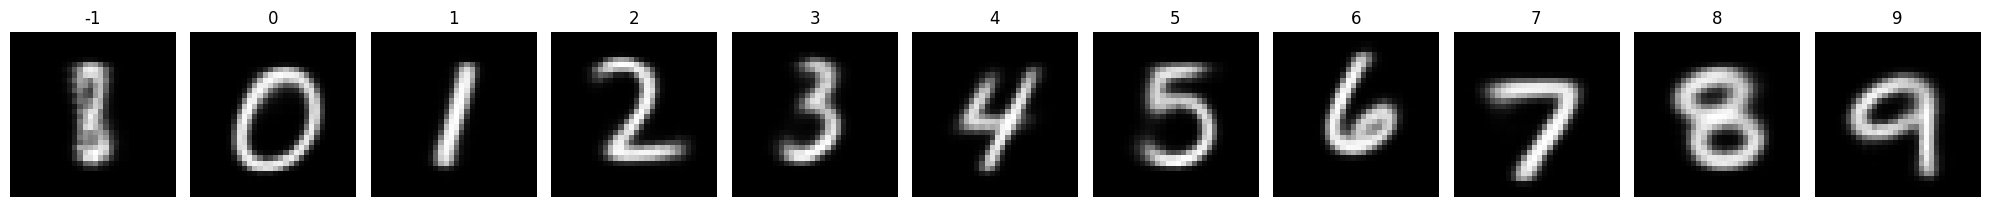

Epoch 68/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1242 - noise_loss: 0.0853 - kl_loss: 3.8879 - val_loss: 0.1231 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.8820 - learning_rate: 0.0012


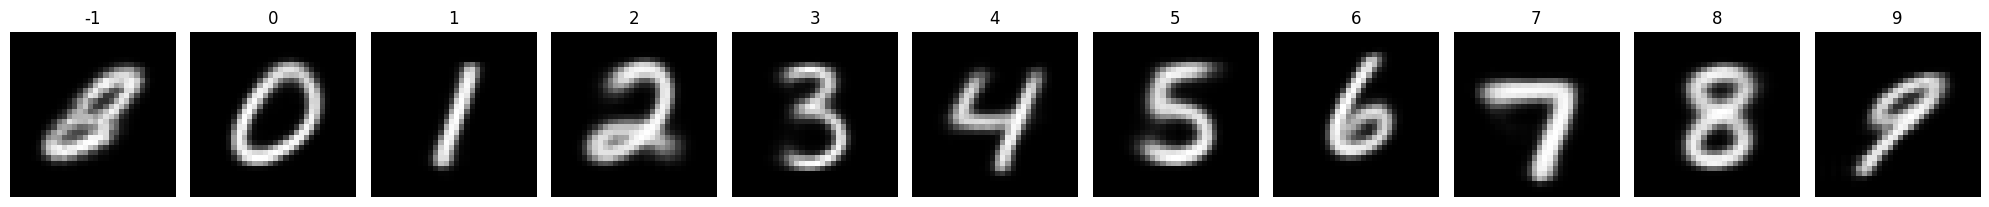

Epoch 69/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1241 - noise_loss: 0.0851 - kl_loss: 3.9077 - val_loss: 0.1231 - val_noise_loss: 0.0842 - val_image_loss: 0.0842 - val_kl_loss: 3.8896 - learning_rate: 0.0011


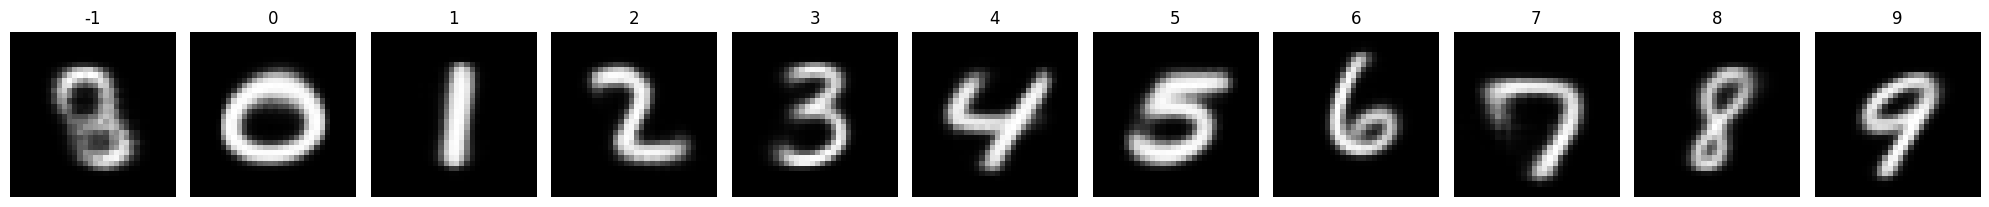

Epoch 70/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1241 - noise_loss: 0.0849 - kl_loss: 3.9128 - val_loss: 0.1231 - val_noise_loss: 0.0842 - val_image_loss: 0.0842 - val_kl_loss: 3.8954 - learning_rate: 0.0010


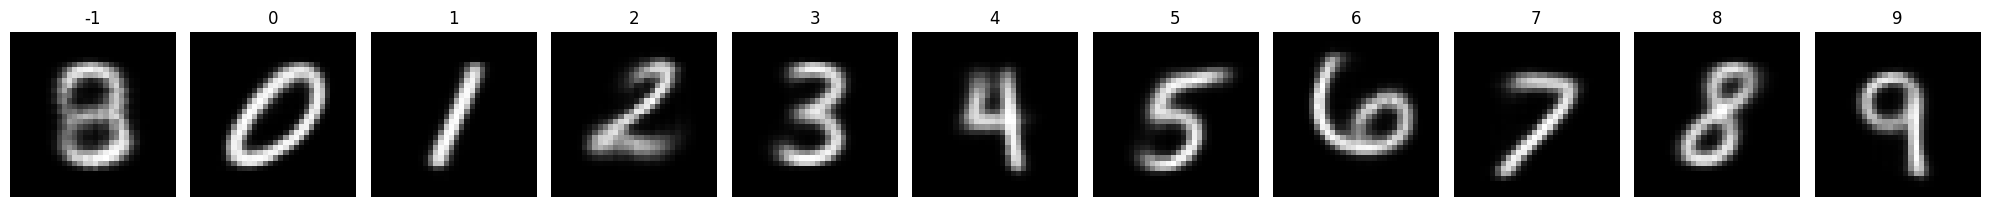

Epoch 71/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1241 - noise_loss: 0.0848 - kl_loss: 3.9284 - val_loss: 0.1234 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.9053 - learning_rate: 9.6773e-04


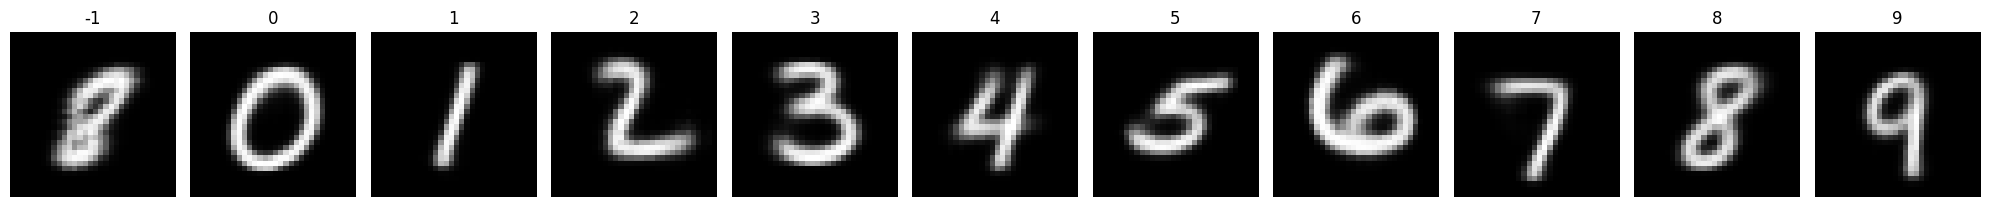

Epoch 72/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1239 - noise_loss: 0.0847 - kl_loss: 3.9249 - val_loss: 0.1234 - val_noise_loss: 0.0843 - val_image_loss: 0.0843 - val_kl_loss: 3.9109 - learning_rate: 9.0644e-04


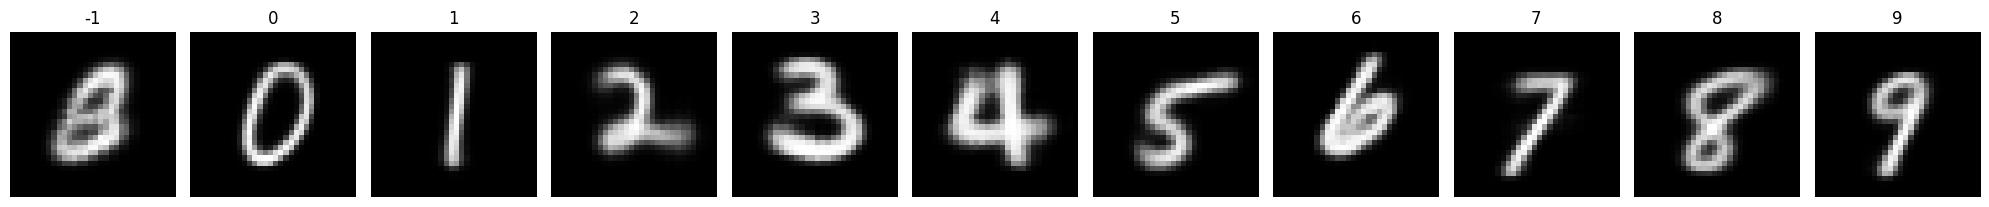

Epoch 73/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1239 - noise_loss: 0.0846 - kl_loss: 3.9260 - val_loss: 0.1232 - val_noise_loss: 0.0840 - val_image_loss: 0.0840 - val_kl_loss: 3.9145 - learning_rate: 8.4672e-04


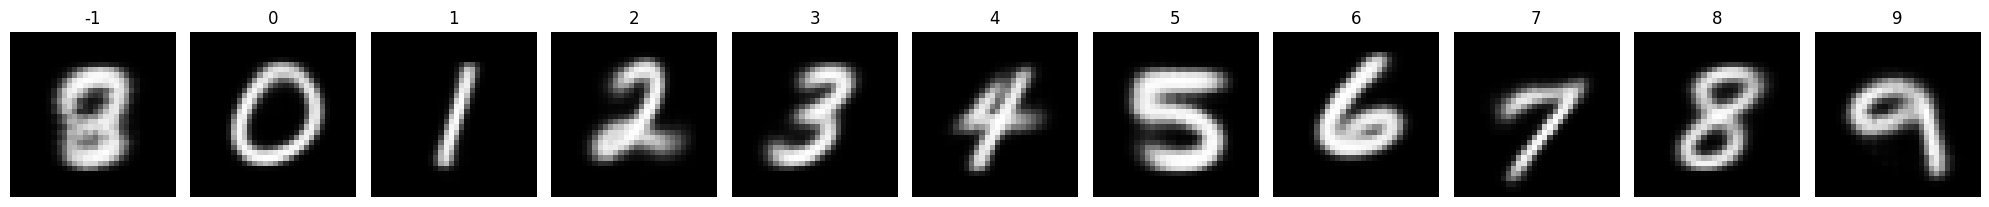

Epoch 74/100
468/468 [==============================] - 55s 117ms/step - loss: 0.1238 - noise_loss: 0.0845 - kl_loss: 3.9387 - val_loss: 0.1228 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9208 - learning_rate: 7.8863e-04


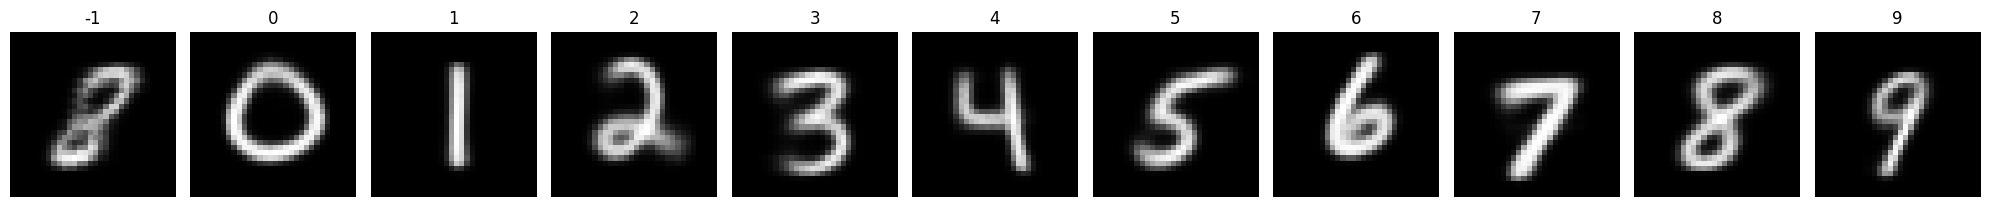

Epoch 75/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1236 - noise_loss: 0.0843 - kl_loss: 3.9280 - val_loss: 0.1228 - val_noise_loss: 0.0836 - val_image_loss: 0.0836 - val_kl_loss: 3.9203 - learning_rate: 7.3223e-04


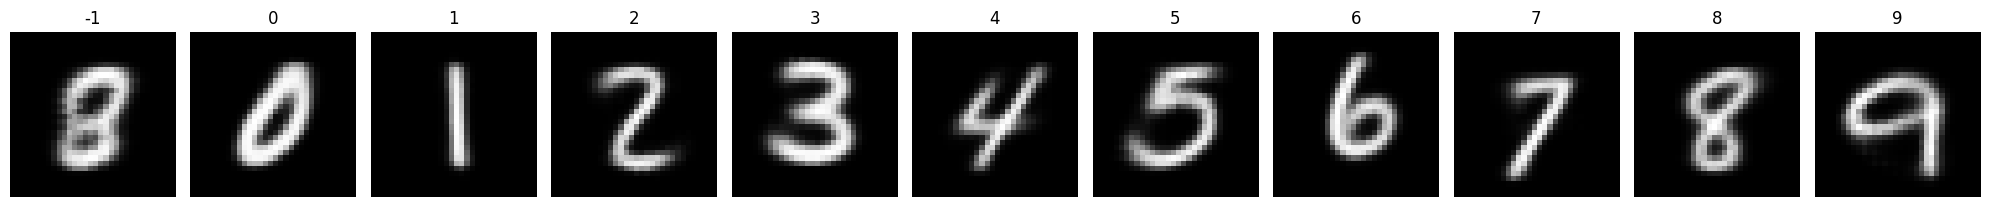

Epoch 76/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1237 - noise_loss: 0.0843 - kl_loss: 3.9444 - val_loss: 0.1230 - val_noise_loss: 0.0838 - val_image_loss: 0.0838 - val_kl_loss: 3.9245 - learning_rate: 6.7758e-04


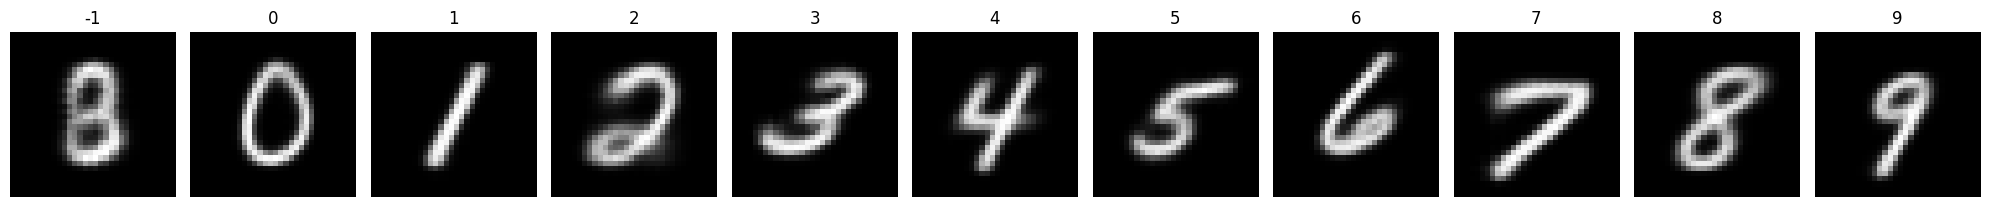

Epoch 77/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1235 - noise_loss: 0.0841 - kl_loss: 3.9393 - val_loss: 0.1230 - val_noise_loss: 0.0837 - val_image_loss: 0.0837 - val_kl_loss: 3.9268 - learning_rate: 6.2472e-04


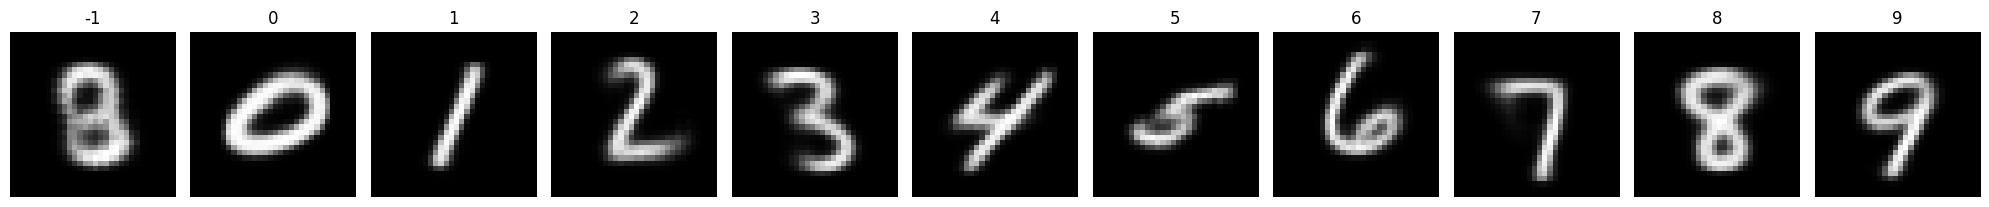

Epoch 78/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1237 - noise_loss: 0.0840 - kl_loss: 3.9690 - val_loss: 0.1231 - val_noise_loss: 0.0837 - val_image_loss: 0.0837 - val_kl_loss: 3.9378 - learning_rate: 5.7372e-04


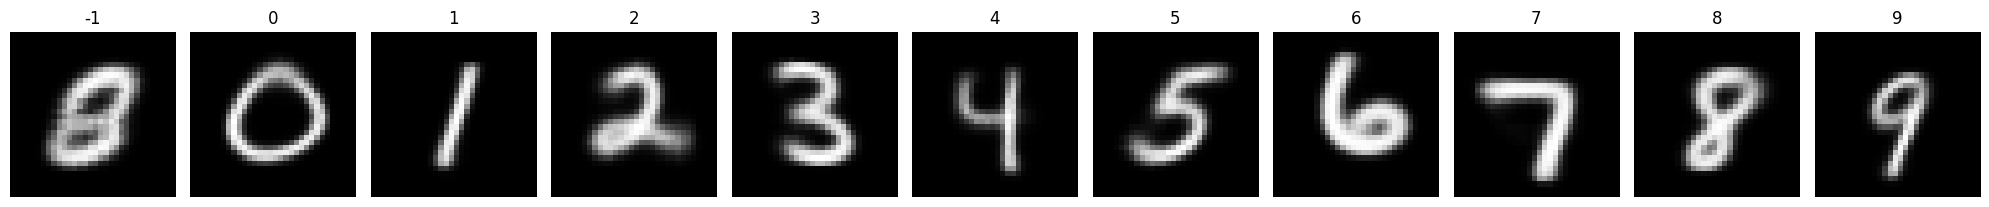

Epoch 79/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1234 - noise_loss: 0.0839 - kl_loss: 3.9566 - val_loss: 0.1229 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9411 - learning_rate: 5.2461e-04


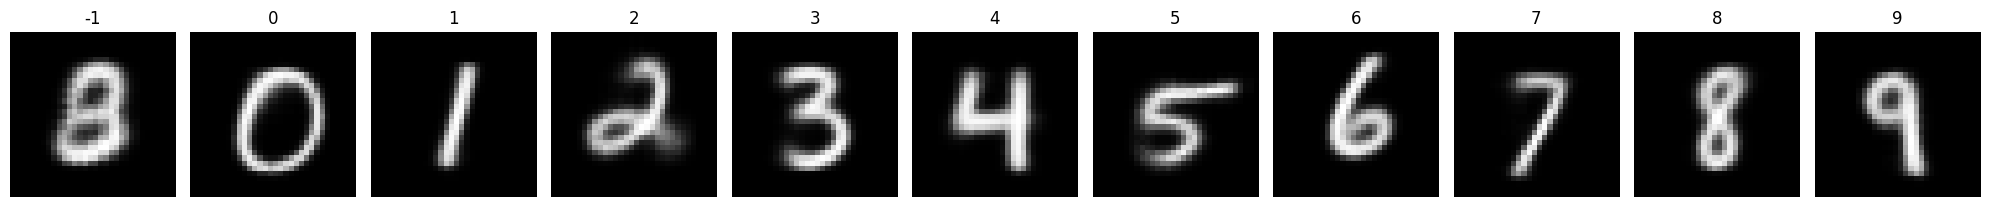

Epoch 80/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1233 - noise_loss: 0.0838 - kl_loss: 3.9502 - val_loss: 0.1232 - val_noise_loss: 0.0838 - val_image_loss: 0.0838 - val_kl_loss: 3.9401 - learning_rate: 4.7746e-04


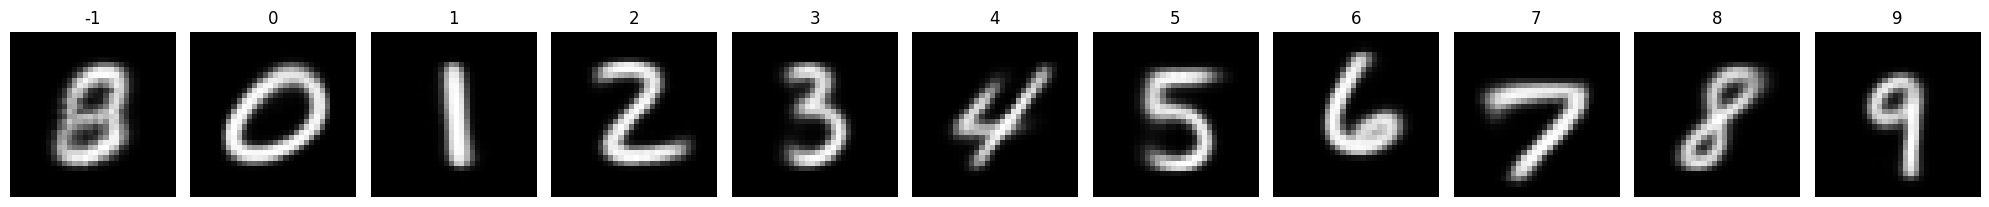

Epoch 81/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1234 - noise_loss: 0.0837 - kl_loss: 3.9657 - val_loss: 0.1232 - val_noise_loss: 0.0837 - val_image_loss: 0.0837 - val_kl_loss: 3.9438 - learning_rate: 4.3230e-04


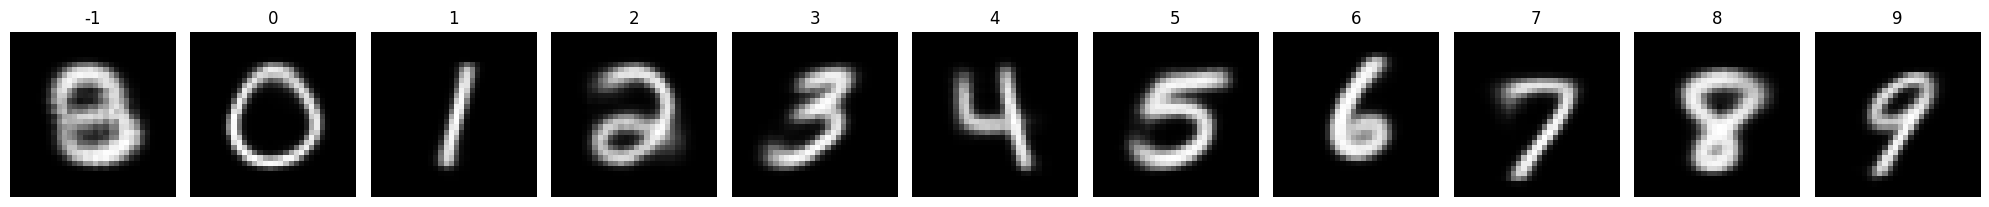

Epoch 82/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1232 - noise_loss: 0.0836 - kl_loss: 3.9563 - val_loss: 0.1229 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9423 - learning_rate: 3.8918e-04


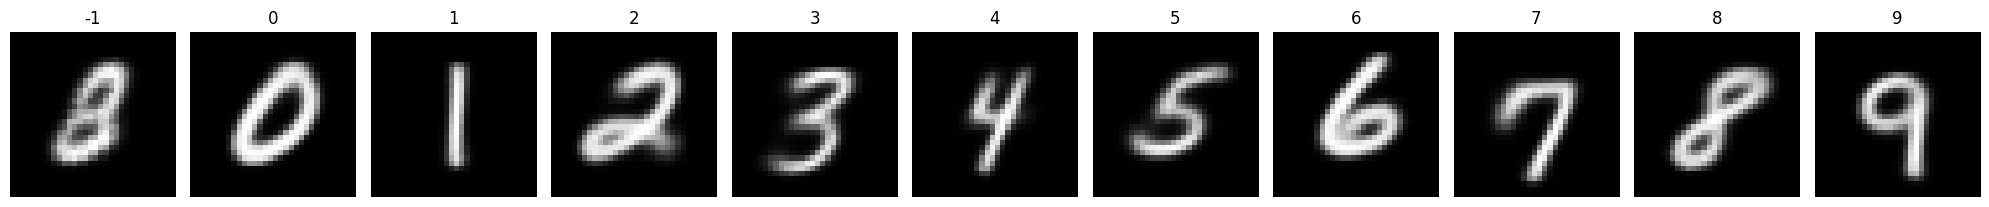

Epoch 83/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1231 - noise_loss: 0.0835 - kl_loss: 3.9628 - val_loss: 0.1230 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9440 - learning_rate: 3.4814e-04


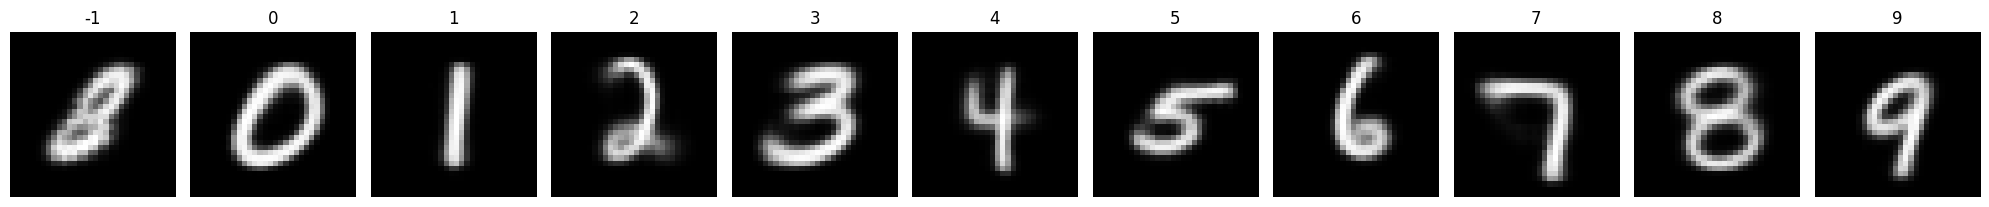

Epoch 84/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1231 - noise_loss: 0.0834 - kl_loss: 3.9703 - val_loss: 0.1230 - val_noise_loss: 0.0836 - val_image_loss: 0.0836 - val_kl_loss: 3.9470 - learning_rate: 3.0923e-04


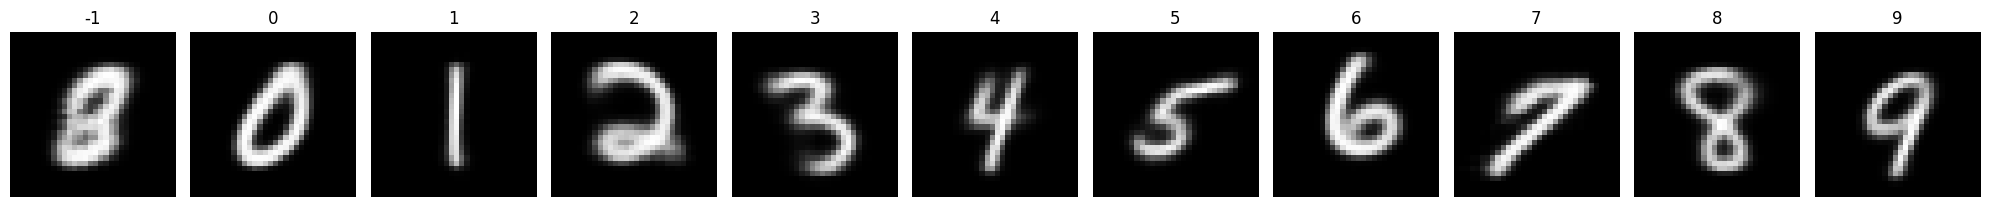

Epoch 85/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1232 - noise_loss: 0.0833 - kl_loss: 3.9843 - val_loss: 0.1231 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9546 - learning_rate: 2.7248e-04


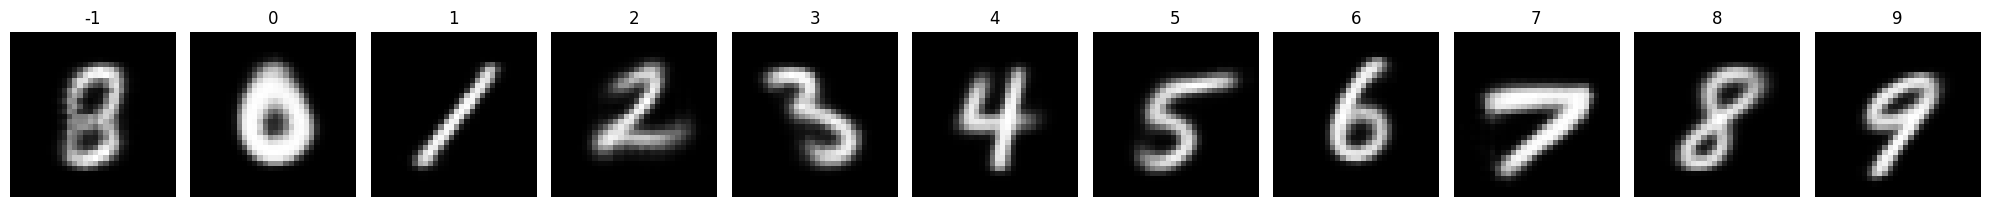

Epoch 86/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1230 - noise_loss: 0.0833 - kl_loss: 3.9775 - val_loss: 0.1230 - val_noise_loss: 0.0835 - val_image_loss: 0.0835 - val_kl_loss: 3.9558 - learning_rate: 2.3793e-04


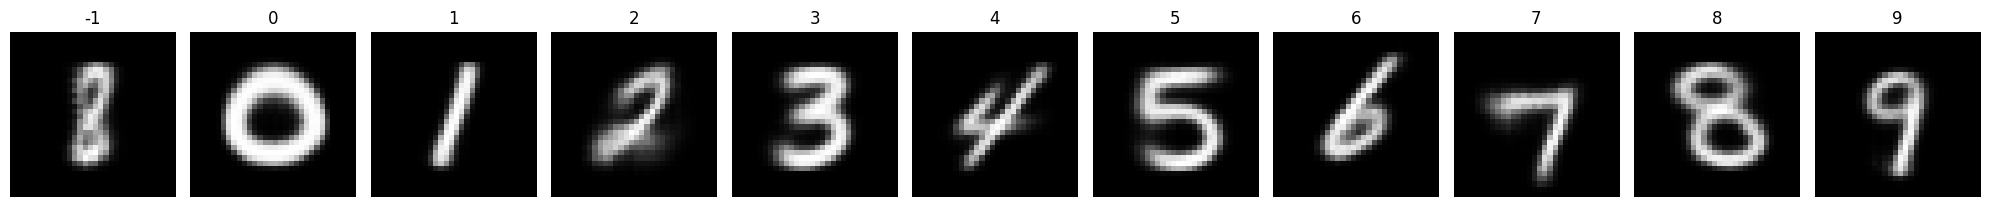

Epoch 87/100
468/468 [==============================] - 55s 117ms/step - loss: 0.1230 - noise_loss: 0.0832 - kl_loss: 3.9823 - val_loss: 0.1229 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9585 - learning_rate: 2.0561e-04


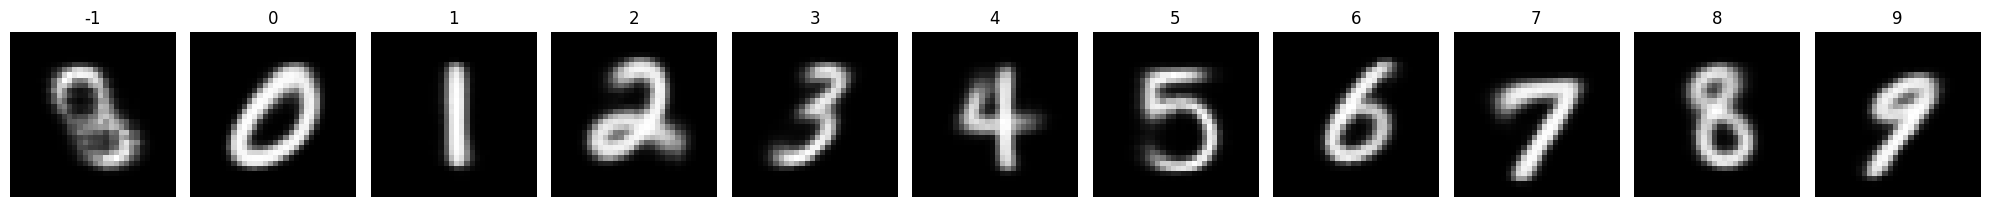

Epoch 88/100
468/468 [==============================] - 55s 118ms/step - loss: 0.1230 - noise_loss: 0.0831 - kl_loss: 3.9853 - val_loss: 0.1230 - val_noise_loss: 0.0834 - val_image_loss: 0.0834 - val_kl_loss: 3.9612 - learning_rate: 1.7556e-04


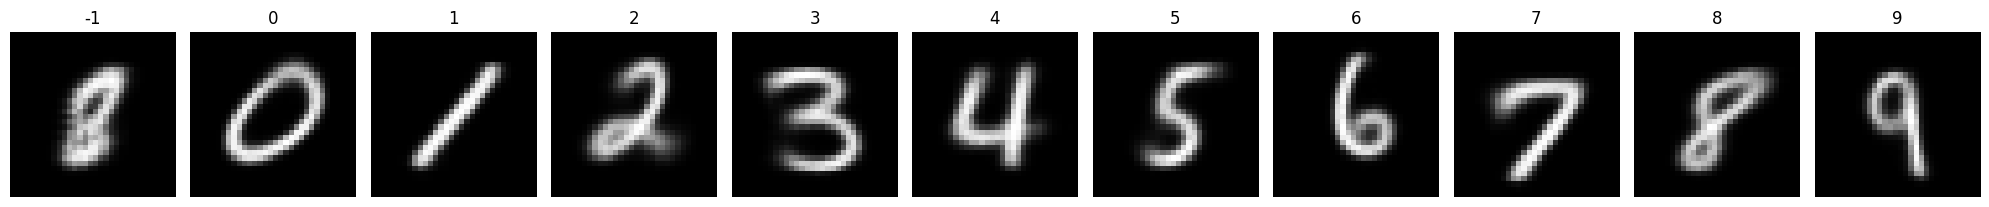

Epoch 89/100
468/468 [==============================] - 56s 120ms/step - loss: 0.1230 - noise_loss: 0.0831 - kl_loss: 3.9916 - val_loss: 0.1229 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9649 - learning_rate: 1.4780e-04


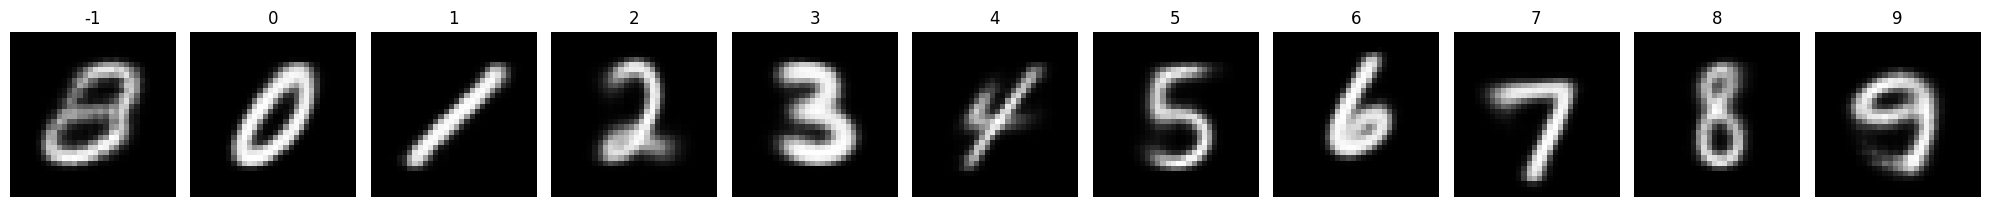

Epoch 90/100
468/468 [==============================] - 53s 114ms/step - loss: 0.1229 - noise_loss: 0.0830 - kl_loss: 3.9856 - val_loss: 0.1228 - val_noise_loss: 0.0831 - val_image_loss: 0.0831 - val_kl_loss: 3.9643 - learning_rate: 1.2236e-04


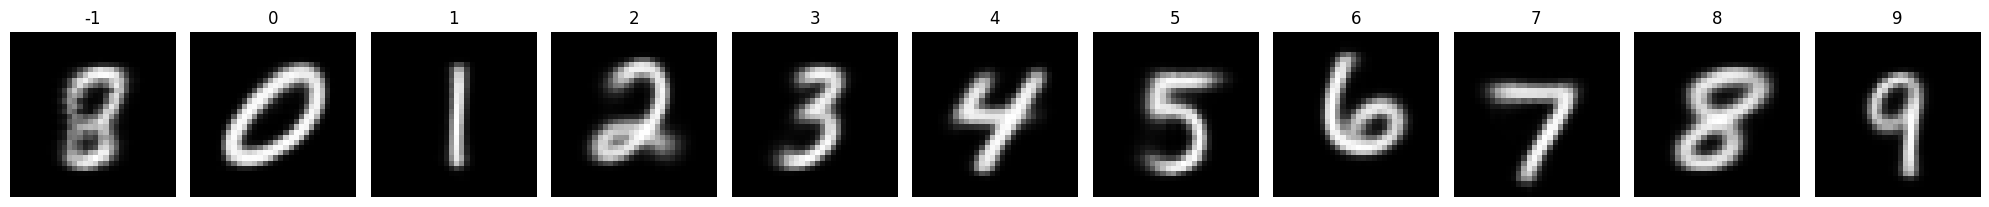

Epoch 91/100
468/468 [==============================] - 53s 114ms/step - loss: 0.1229 - noise_loss: 0.0830 - kl_loss: 3.9910 - val_loss: 0.1231 - val_noise_loss: 0.0834 - val_image_loss: 0.0834 - val_kl_loss: 3.9659 - learning_rate: 9.9266e-05


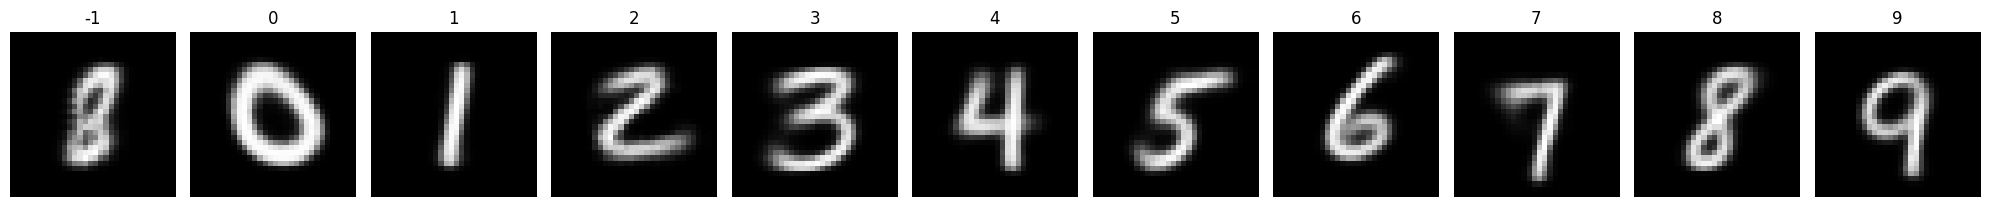

Epoch 92/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1229 - noise_loss: 0.0829 - kl_loss: 4.0005 - val_loss: 0.1230 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9704 - learning_rate: 7.8542e-05


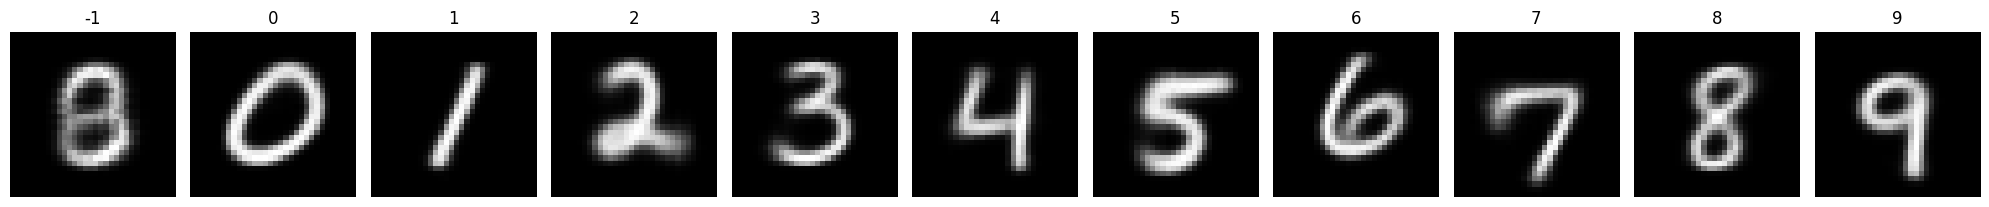

Epoch 93/100
468/468 [==============================] - 51s 109ms/step - loss: 0.1229 - noise_loss: 0.0828 - kl_loss: 4.0051 - val_loss: 0.1228 - val_noise_loss: 0.0831 - val_image_loss: 0.0831 - val_kl_loss: 3.9748 - learning_rate: 6.0208e-05


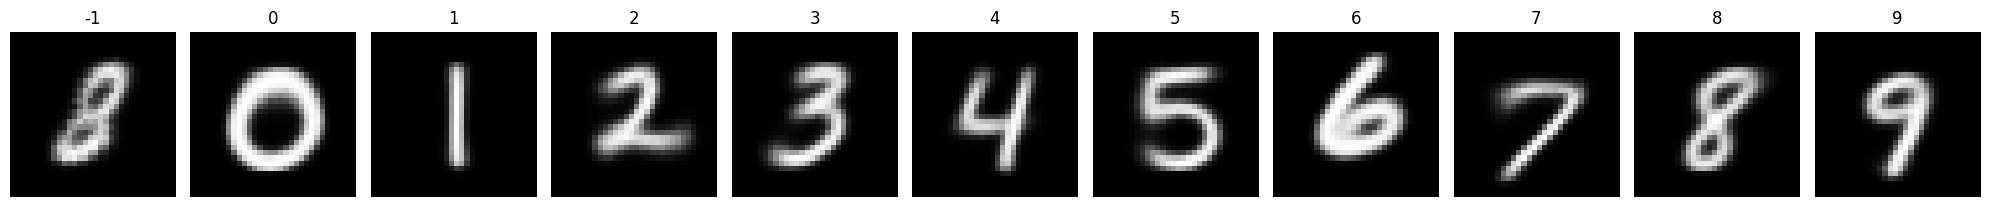

Epoch 94/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1230 - noise_loss: 0.0829 - kl_loss: 4.0000 - val_loss: 0.1230 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9751 - learning_rate: 4.4282e-05


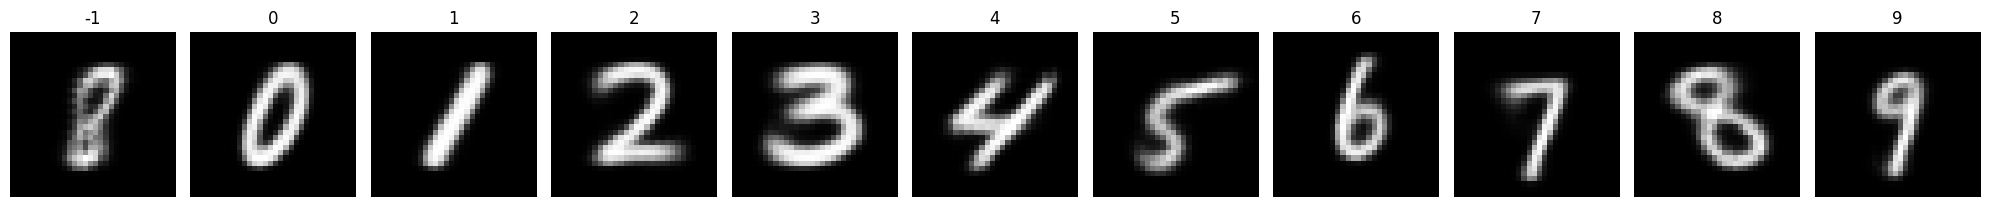

Epoch 95/100
468/468 [==============================] - 57s 123ms/step - loss: 0.1229 - noise_loss: 0.0828 - kl_loss: 4.0018 - val_loss: 0.1230 - val_noise_loss: 0.0832 - val_image_loss: 0.0832 - val_kl_loss: 3.9761 - learning_rate: 3.0779e-05


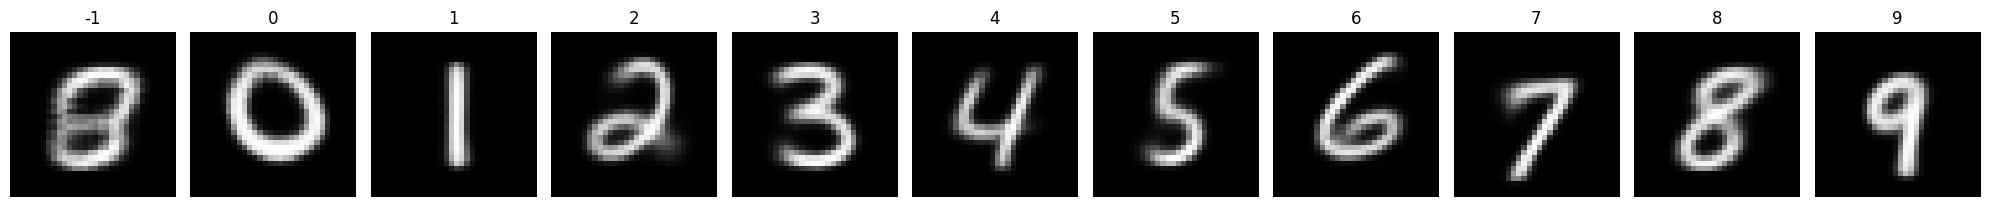

Epoch 96/100
468/468 [==============================] - 60s 127ms/step - loss: 0.1228 - noise_loss: 0.0827 - kl_loss: 4.0052 - val_loss: 0.1231 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9778 - learning_rate: 1.9713e-05


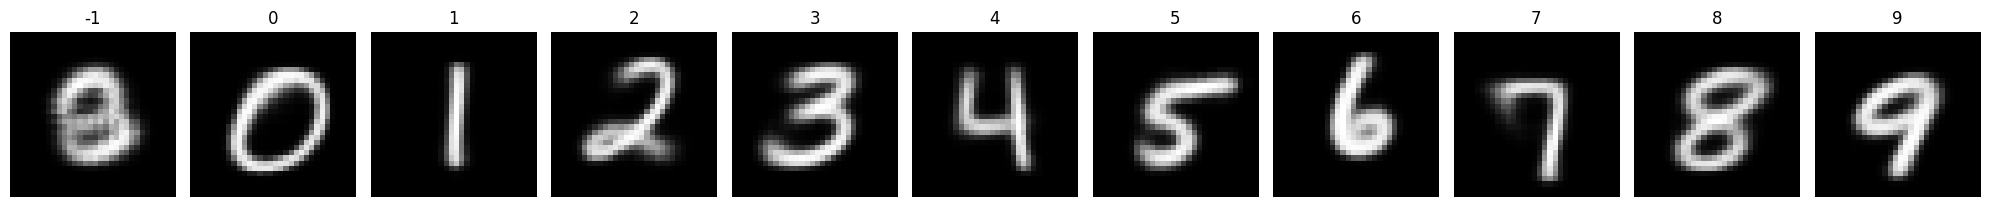

Epoch 97/100
468/468 [==============================] - 56s 120ms/step - loss: 0.1228 - noise_loss: 0.0828 - kl_loss: 4.0015 - val_loss: 0.1227 - val_noise_loss: 0.0829 - val_image_loss: 0.0829 - val_kl_loss: 3.9776 - learning_rate: 1.1095e-05


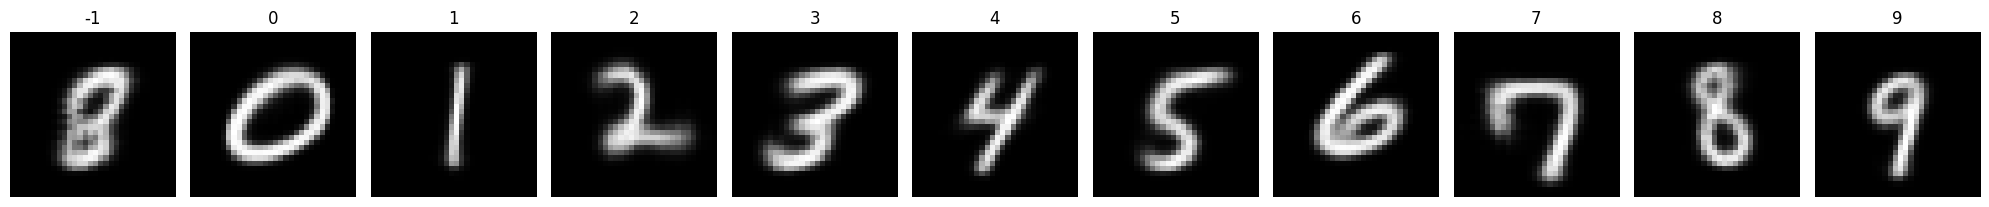

Epoch 98/100
468/468 [==============================] - 56s 119ms/step - loss: 0.1227 - noise_loss: 0.0826 - kl_loss: 4.0025 - val_loss: 0.1228 - val_noise_loss: 0.0830 - val_image_loss: 0.0830 - val_kl_loss: 3.9776 - learning_rate: 4.9332e-06


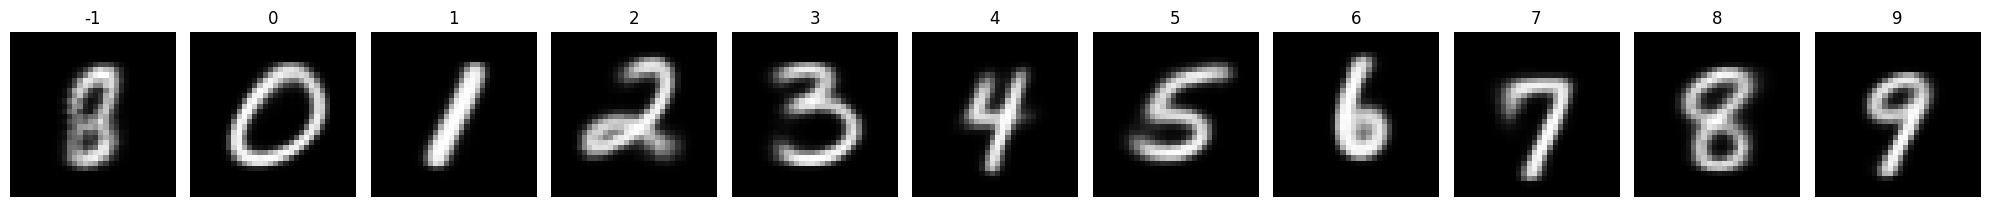

Epoch 99/100
468/468 [==============================] - 54s 116ms/step - loss: 0.1228 - noise_loss: 0.0828 - kl_loss: 4.0008 - val_loss: 0.1228 - val_noise_loss: 0.0830 - val_image_loss: 0.0830 - val_kl_loss: 3.9773 - learning_rate: 1.2337e-06


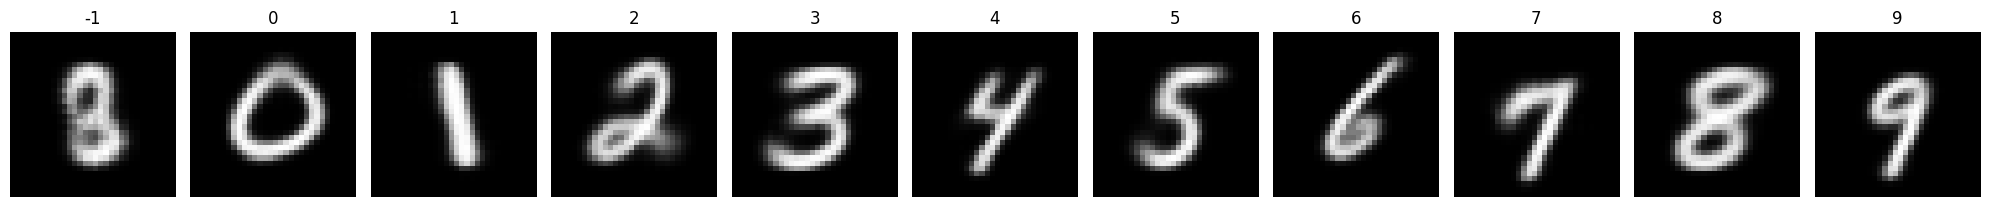

Epoch 100/100
468/468 [==============================] - 54s 115ms/step - loss: 0.1227 - noise_loss: 0.0827 - kl_loss: 4.0014 - val_loss: 0.1230 - val_noise_loss: 0.0833 - val_image_loss: 0.0833 - val_kl_loss: 3.9774 - learning_rate: 0.0000e+00


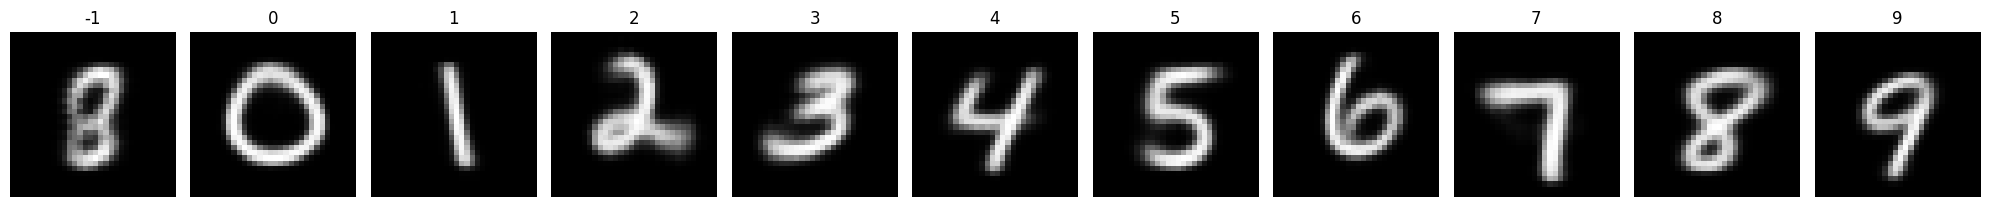

In [8]:
history1 = model.fit_generator(
    x=trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [9]:
history2 = model.fit_discriminator(
    x=trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list[:-1]
).history

Epoch 1/100
468/468 [==============================] - 27s 45ms/step - classifier_loss: 0.3913 - classifier_accuracy: 0.8717 - val_classifier_loss: 1.8926 - val_classifier_accuracy: 0.5344 - learning_rate: 0.0050
Epoch 2/100
468/468 [==============================] - 17s 35ms/step - classifier_loss: 0.2067 - classifier_accuracy: 0.9362 - val_classifier_loss: 1.0860 - val_classifier_accuracy: 0.8612 - learning_rate: 0.0050
Epoch 3/100
468/468 [==============================] - 16s 34ms/step - classifier_loss: 0.1779 - classifier_accuracy: 0.9454 - val_classifier_loss: 0.4495 - val_classifier_accuracy: 0.9392 - learning_rate: 0.0050
Epoch 4/100
468/468 [==============================] - 21s 45ms/step - classifier_loss: 0.1607 - classifier_accuracy: 0.9510 - val_classifier_loss: 0.2019 - val_classifier_accuracy: 0.9594 - learning_rate: 0.0050
Epoch 5/100
468/468 [==============================] - 19s 41ms/step - classifier_loss: 0.1538 - classifier_accuracy: 0.9523 - val_classifier_loss: 

In [10]:
history = model.merge_result_dicts((history1, history2))

In [ ]:
model.save_weights("./models/VAE U-DiT CLFV2/model.weights.h5")

In [13]:
model.evaluate(x=valset, eval_both=True, network_name="ema")

79/79 [==============================] - 22s 262ms/step - classifier_loss: 0.2011 - classifier_accuracy: 0.9760


{'loss': 0.1228240504860878,
 'noise_loss': 0.08305013179779053,
 'image_loss': 0.08305013179779053,
 'kl_loss': 3.9773917198181152,
 'classifier_loss': 0.20108038187026978,
 'classifier_accuracy': 0.9760000109672546}

In [14]:
model.evaluate(x=valset, eval_both=True, network_name="raw")

79/79 [==============================] - 23s 271ms/step - classifier_loss: 0.2020 - classifier_accuracy: 0.9762


{'loss': 0.12290335446596146,
 'noise_loss': 0.08313041180372238,
 'image_loss': 0.08313041180372238,
 'kl_loss': 3.977294445037842,
 'classifier_loss': 0.20197680592536926,
 'classifier_accuracy': 0.9761999845504761}

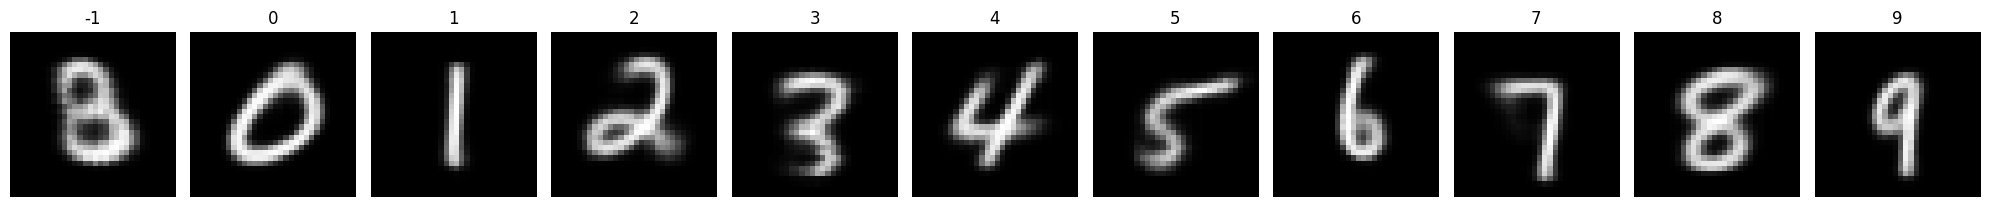

In [15]:
from common.utils import plot_images


imgs = model.sample_vae(add_null_label=True)
plot_images(imgs, has_null_label=True)

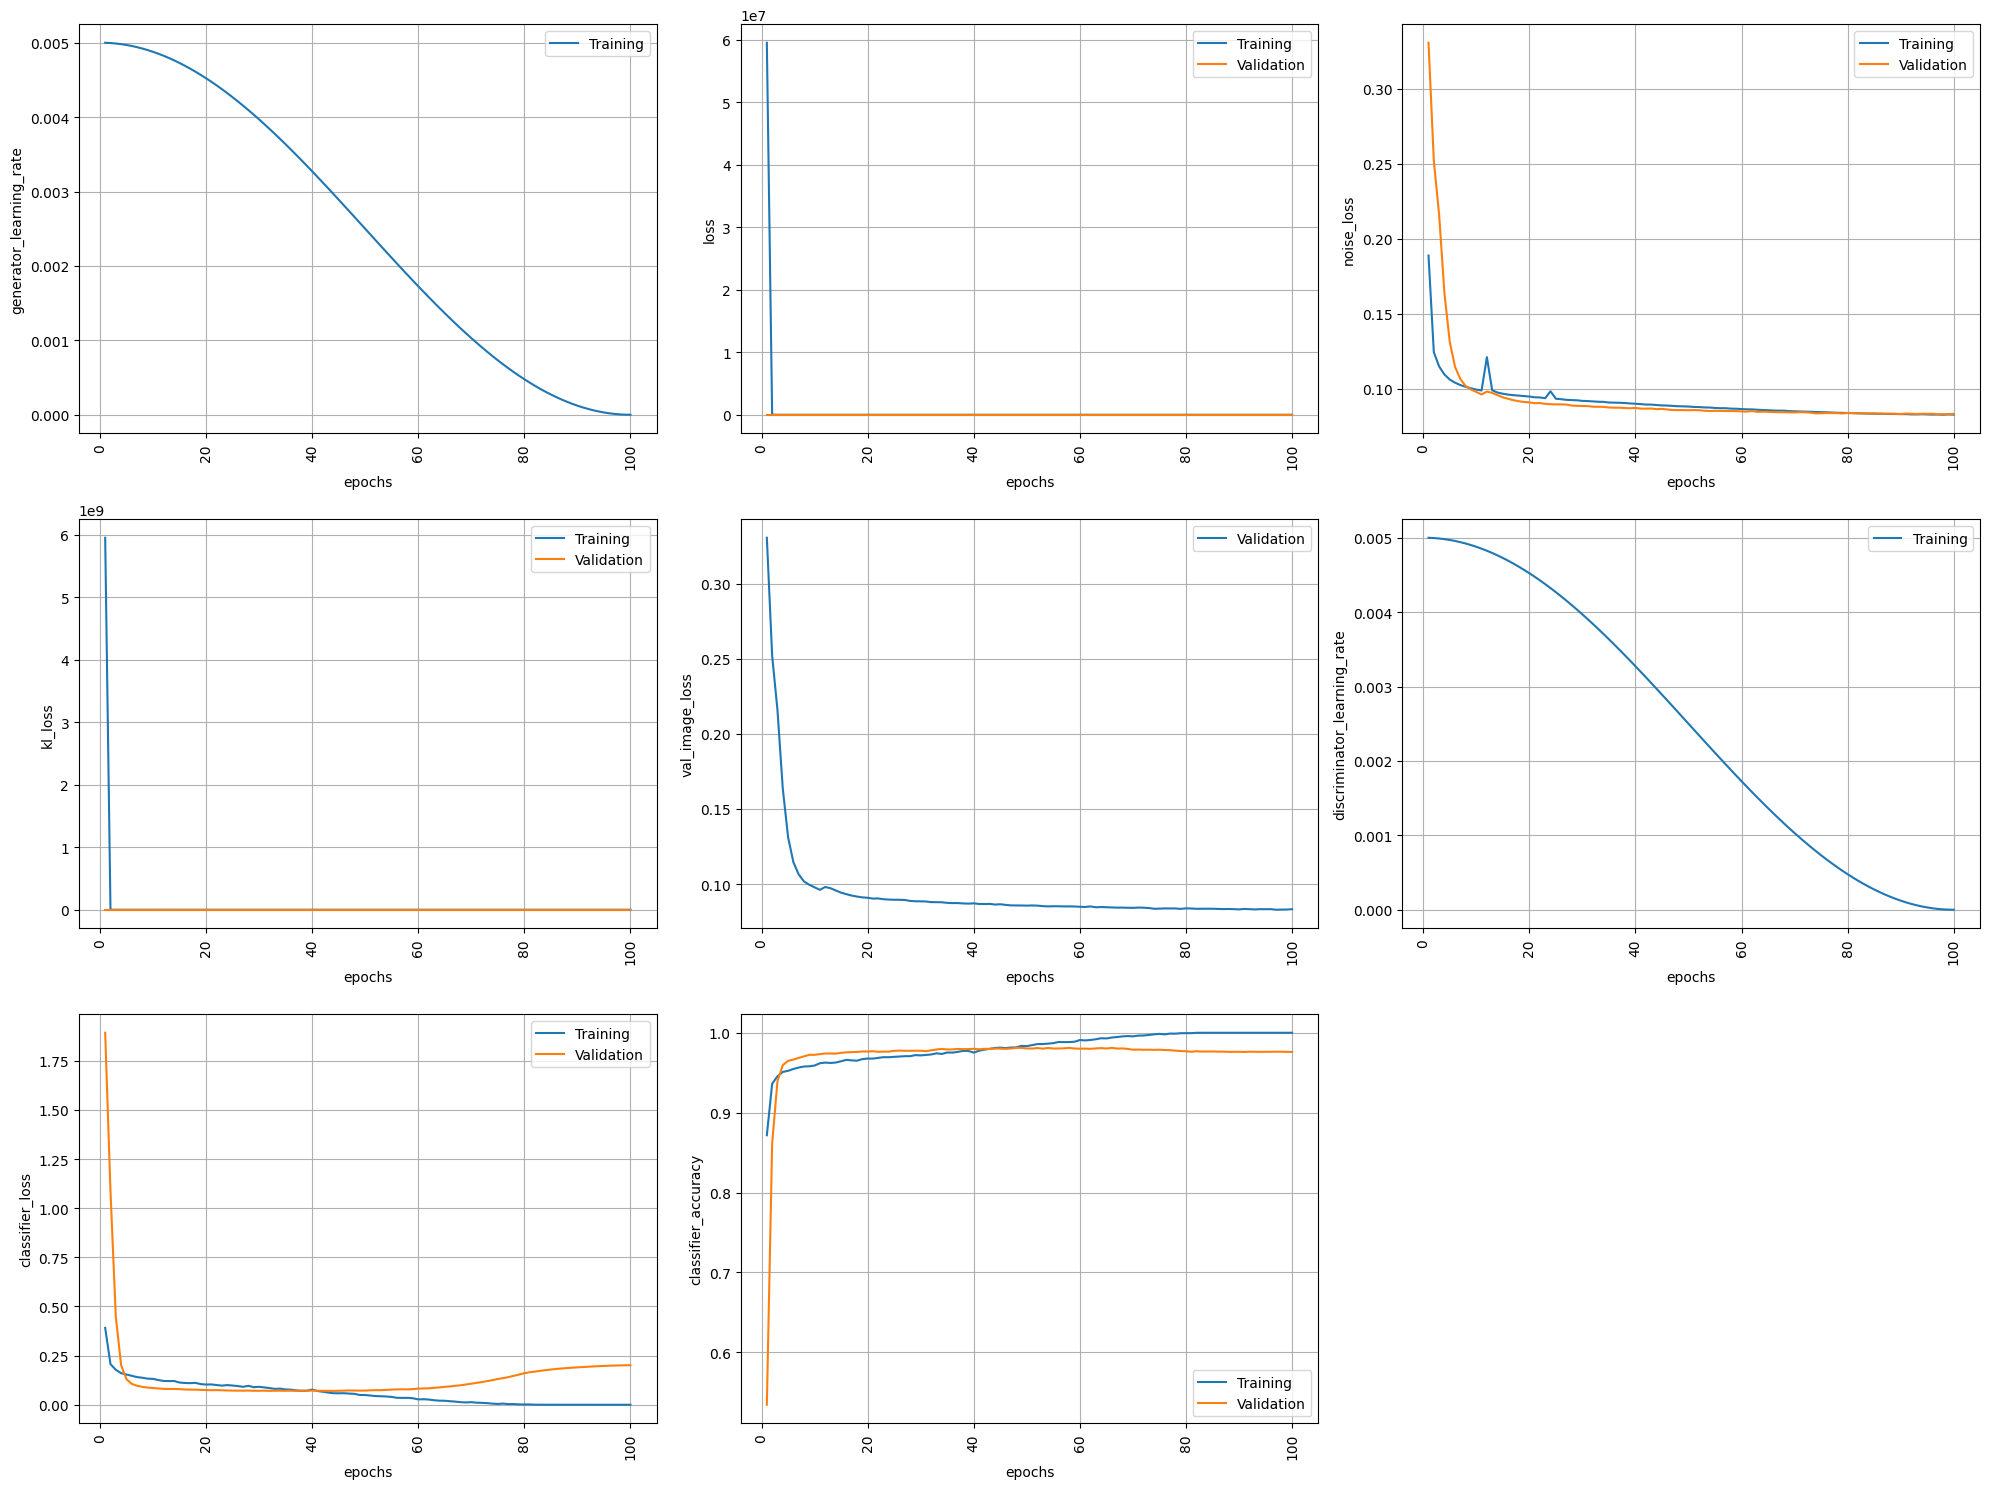

In [16]:
from common.utils import plot_history


plot_history(history)

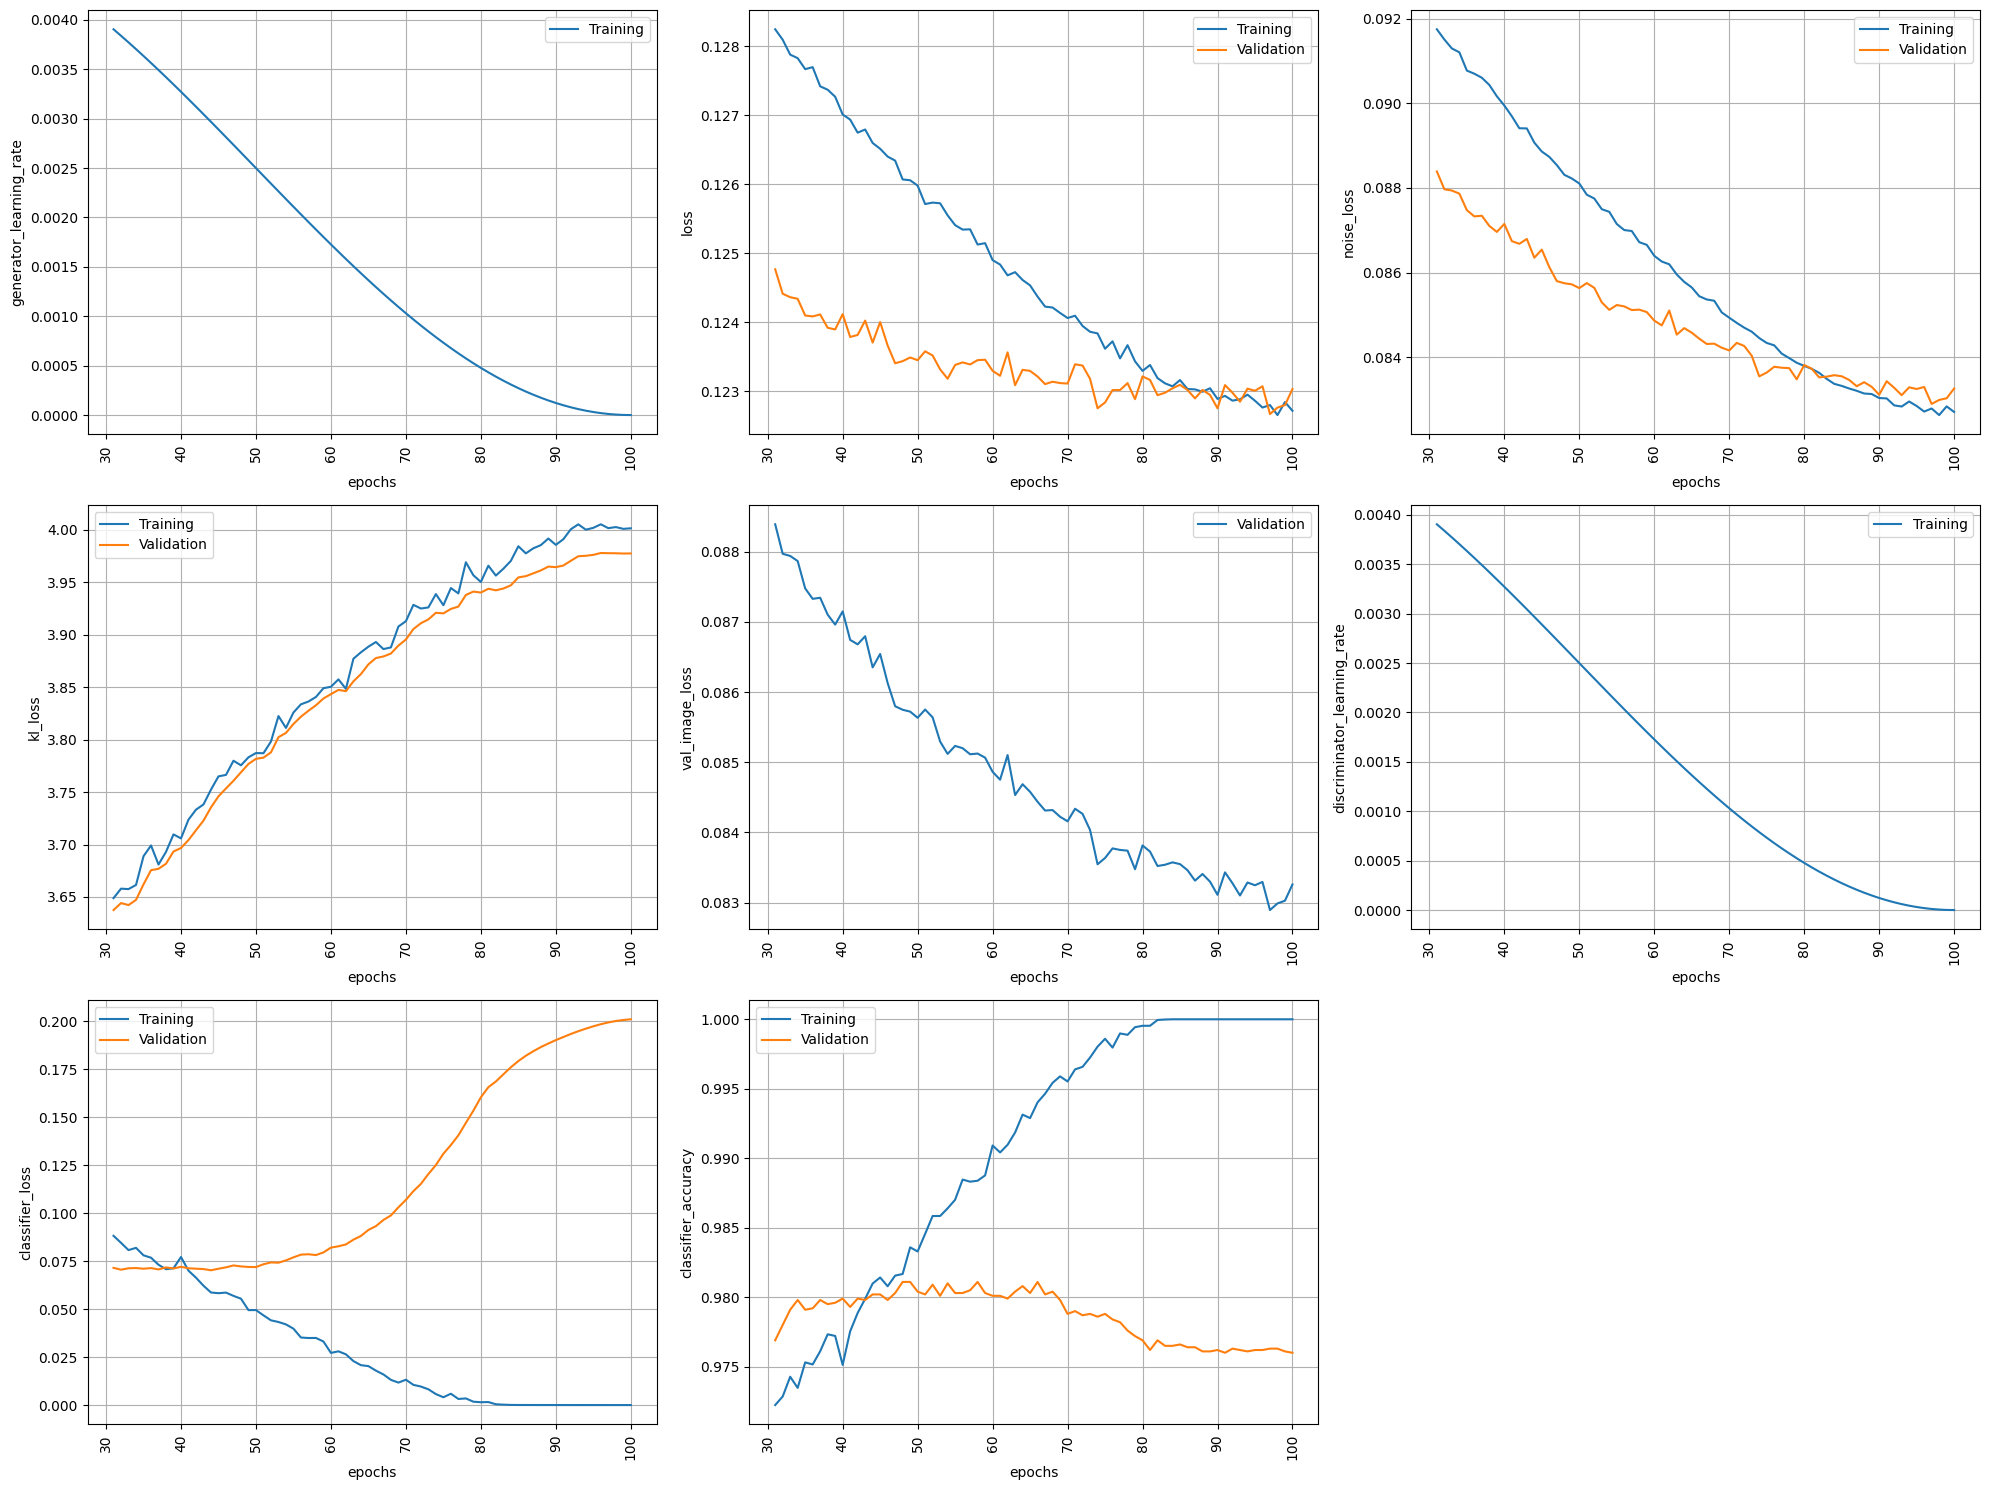

In [19]:
plot_history(history, show_all_x_ticks=False, range_=(30, None))